# Time-series EDA: `tunindex_timeseries.csv`

Descriptive exploration of the analysis frame (3,179 sessions x 65 columns, 2014-01-02 to 2026-09-16).
Reads **one CSV** (`data/curated/tunindex_timeseries.csv`) and quotes **one JSON** (`hypothesis_results.json`) in §9.
Writes nothing under `data/`.

> **Headline (section B1, directly after §1):** the CamemBERT instrument behaves differently before and after 2019.
> In 2016-18 almost every price report is scored -1 and the placebo score agrees with the direction of the session it
> describes at chance level; from 2019 it agrees most of the time. Every pooled sentiment statistic averages across
> this. From B1 on, sentiment tables are shown **per era (2016-18 / 2019+)**. The 2019 boundary was **chosen post hoc
> after inspecting the B1 table**; it is a description of the instrument, not an estimated break and not an H1 result.

This notebook does **not** test H1, fit predictive models, or compute AUC. The H1 verdict is quoted from
`hypothesis_results.json`; no new verdict is formed here.

Standing guards, applied in every section:
- Returns are close-to-close `ret`. `open` is not in the frame and is never loaded.
- No `.shift()` on any `sent_*`, `*_lag*` or `ret_next` column. `sent_*_lag1[i]` already pairs with `ret_next[i]`.
  Neighbour comparisons use `ret_lag1`, `ret_next` or array slicing.
- Sentiment statistics use only rows where the arm's **own** `has_sent_*==1`. Zeros on unscored sessions are fills, not neutral.
- CamemBERT (`sent_*_lag1`) and TF-IDF (`sent_*_tfidf_lag1`) are different instruments and are never pooled.
- No row is dropped or patched. Robustness views (B3) are descriptions, not cleaning.

In [1]:
import json, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import Markdown, display
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch, breaks_cusumolsresid
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint
from statsmodels.tools.sm_exceptions import InterpolationWarning

warnings.simplefilter("ignore", InterpolationWarning)  # KPSS p-values outside the table are clipped; printed as bounds
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
sns.set_theme(style="whitegrid", context="notebook")

FIG = "/tmp/claude-1001/-home-yacin-Desktop-Documents-NLP-ProjectNLP/4569354c-af42-4542-af20-7e929ffd326e/scratchpad/eda/fig"
os.makedirs(FIG, exist_ok=True)

def save(fig, name):
    fig.tight_layout()
    fig.savefig(f"{FIG}/{name}.png", dpi=110, bbox_inches="tight")
    plt.show()

def wilson(k, n):
    lo, hi = proportion_confint(k, n, method="wilson")
    return lo, hi

# Regime bands: picked BY EYE after looking at the price chart. Not estimated break dates.
COVID = (pd.Timestamp("2020-03-01"), pd.Timestamp("2020-06-30"))
RALLY_START = pd.Timestamp("2025-01-01")

def shade(ax, end):
    ax.axvspan(*COVID, color="tab:red", alpha=0.12, label="COVID band (eye-picked)")
    ax.axvspan(RALLY_START, end, color="tab:orange", alpha=0.12, label="2025-26 rally (eye-picked)")

## §1 Load and assert

**Question:** is this the frame the spec describes? Every fact recomputed on 2026-09-29 is asserted below.
**Pitfall guarded:** analysing a frame that silently changed. If any assertion fails, the notebook stops;
nothing is "fixed" here. `open` is not in the frame and is not merged back from `bvmt/`.

In [2]:
df = pd.read_csv("data/curated/tunindex_timeseries.csv", parse_dates=["session"])
print("shape:", df.shape, "| range:", df.session.min().date(), "->", df.session.max().date())
print(df.dtypes.value_counts().to_string())
nulls = df.isna().sum()
nulls = nulls[nulls > 0]
print("\nNull table (columns with any null):")
print(nulls.to_string())

shape: (3179, 65) | range: 2014-01-02 -> 2026-09-16
float64           51
int64             13
datetime64[ns]     1

Null table (columns with any null):
ret_next                  1
dow_next_mon              1
dow_next_tue              1
dow_next_wed              1
dow_next_thu              1
sent_mean_tfidf_lag1    503
sent_n_tfidf_lag1       503


In [3]:
DOW = ["dow_next_mon", "dow_next_tue", "dow_next_wed", "dow_next_thu"]
ARMS = {  # arm -> (sentiment mean column, the arm's own coverage flag)
    "all":        ("sent_mean_lag1",            "has_sent_lag1"),
    "ex_price":   ("sent_mean_ex_price_lag1",   "has_sent_ex_price_lag1"),
    "placebo":    ("sent_mean_price_only_lag1", "has_sent_price_only_lag1"),
}
RESID = {"all": "sent_resid_lag1", "ex_price": "sent_resid_ex_price_lag1", "placebo": "sent_resid_price_only_lag1"}
YEAR = df.session.dt.year

# shape / range / no open
assert df.shape == (3179, 65)
assert df.session.min() == pd.Timestamp("2014-01-02") and df.session.max() == pd.Timestamp("2026-09-16")
assert "open" not in df.columns
assert df.session.is_monotonic_increasing and df.session.is_unique

# nulls
assert set(nulls.index) == {"ret_next", *DOW, "sent_mean_tfidf_lag1", "sent_n_tfidf_lag1"}
for c in ["ret_next", *DOW]:
    assert nulls[c] == 1 and pd.isna(df[c].iloc[-1]), c
assert nulls["sent_mean_tfidf_lag1"] == 503 and nulls["sent_n_tfidf_lag1"] == 503

# identities
assert (df.ret_lag0 == df.ret).all()
assert (df.log_headlines_lag0 == df.log_headlines).all()
assert ((df.sent_n > 0) == (df.has_sent_lag1 == 1)).all()
assert (df.has_sent_lag1 == df.has_sent_ex_price_lag1).all()        # the two flags are identical on every row
assert (df.sent_n_ex_price + df.sent_n_price_only == df.sent_n).all()
assert (df.n_price_reports + df.n_non_price == df.n_headlines).all()
# alignment of the target and lag columns, checked by array slicing (no shift)
assert np.allclose(df.ret_next.values[:-1], df.ret.values[1:])
assert np.allclose(df.ret_lag1.values[1:], df.ret.values[:-1])

# sentiment coverage
assert df.has_sent_lag1.sum() == 2676
unscored = df.loc[df.has_sent_lag1 == 0, "session"]
assert unscored.min() == pd.Timestamp("2014-01-02") and unscored.max() <= pd.Timestamp("2015-12-31") and len(unscored) == 503
FIRST_SCORED = df.loc[df.has_sent_lag1 == 1, "session"].min()
assert FIRST_SCORED == pd.Timestamp("2016-01-04")
assert df.has_sent_price_only_lag1.sum() == 1168
for arm in ARMS:   # "no-sentiment sessions" = has_sent_lag1 == 0 (the 2014-15 blackout)
    assert (df.loc[df.has_sent_lag1 == 0, RESID[arm]] == 0.0).all(), arm   # 0-filled, not residuals
# Observed, not asserted by the spec: on sessions with sentiment but NO price report, the placebo residual is NOT 0.
_pl = df[(df.has_sent_lag1 == 1) & (df.has_sent_price_only_lag1 == 0)]
PL_RESID_NONZERO = int((_pl.sent_resid_price_only_lag1 != 0).sum())

# phantom rows: close, high and low identical to the previous row (array slicing, no shift)
c_, h_, l_ = df.close.values, df.high.values, df.low.values
PHANTOM = pd.Series(np.r_[False, (c_[1:] == c_[:-1]) & (h_[1:] == h_[:-1]) & (l_[1:] == l_[:-1])], index=df.index)
assert PHANTOM.sum() == 19 and (PHANTOM == (df.ret == 0)).all()   # every ret == 0 row is a copied-OHLC row

# target
UP_RATE = (df.ret_next.dropna() > 0).mean()
N_ZERO_TARGET = int((df.ret_next == 0).sum())
assert abs(UP_RATE - 0.542) < 0.001 and N_ZERO_TARGET == 19

# autocorrelation
ACF1_RET, ACF1_ABS = acf(df.ret, nlags=1)[1], acf(df.abs_ret, nlags=1)[1]
assert round(ACF1_RET, 3) == 0.263 and round(ACF1_ABS, 3) == 0.387

# alignment fingerprint, on the FULL frame (0-fills included) as the spec states it
FP_LAG1 = df.sent_mean_price_only_lag1.corr(df.ret_lag1)
FP_LAG0 = df.sent_mean_price_only_lag1.corr(df.ret_lag0)
assert round(FP_LAG1, 3) == 0.227 and round(FP_LAG0, 3) == 0.038

# macro fills and volume
assert (df.brent_is_ffill.sum(), df.stoxx50_is_ffill.sum(), df.eur_tnd_is_ffill.sum()) == (80, 106, 17)
assert (df.volume == 0).sum() == 55 and ((df.volume == 0) & (YEAR == 2026)).sum() == 15

print("All §0 assertions pass.")
print(f"up base rate ret_next>0 = {UP_RATE:.4f} (spec quotes 0.5420; recomputed 4-dp value is {UP_RATE:.4f})")
print(f"ret_next == 0 on {N_ZERO_TARGET} rows. These are NOT flat markets: all 19 ret == 0 rows copy the previous row's OHLC (phantom rows, B2).")
print(f"ACF(1) ret = {ACF1_RET:+.4f}, abs_ret = {ACF1_ABS:+.4f}")
print(f"fingerprint (full frame, incl. 0-fills): corr(placebo, ret_lag1) = {FP_LAG1:+.4f}, corr(placebo, ret_lag0) = {FP_LAG0:+.4f}")
print("first scored session:", FIRST_SCORED.date(), "| has_sent_lag1 == has_sent_ex_price_lag1 on every row")
print(f"NOTE: sent_resid_price_only_lag1 is non-zero on {PL_RESID_NONZERO} of {len(_pl)} sessions where the placebo arm has NO data "
      f"(mean {_pl.sent_resid_price_only_lag1.mean():+.3f}); cause unverified (orphan column, routed to the reproducer in §9). "
      "Every use below filters on has_sent_price_only_lag1 == 1.")

All §0 assertions pass.
up base rate ret_next>0 = 0.5422 (spec quotes 0.5420; recomputed 4-dp value is 0.5422)
ret_next == 0 on 19 rows. These are NOT flat markets: all 19 ret == 0 rows copy the previous row's OHLC (phantom rows, B2).
ACF(1) ret = +0.2628, abs_ret = +0.3869
fingerprint (full frame, incl. 0-fills): corr(placebo, ret_lag1) = +0.2270, corr(placebo, ret_lag0) = +0.0385
first scored session: 2016-01-04 | has_sent_lag1 == has_sent_ex_price_lag1 on every row
NOTE: sent_resid_price_only_lag1 is non-zero on 1507 of 1508 sessions where the placebo arm has NO data (mean +0.138); cause unverified (orphan column, routed to the reproducer in §9). Every use below filters on has_sent_price_only_lag1 == 1.


## B1 (HEADLINE) Instrument era check

**Question:** does the CamemBERT instrument behave the same way in every year?

**Validity check used:** price reports restate the index's own move, so an instrument that reads them correctly must score them
in the direction of the session they describe, `ret_lag1` (the placebo is aligned so that `ret_lag1[i]` is that session).
The table gives, per year: placebo n, the share of placebo scores at exactly -1 / 0 / +1, the sign agreement of the
placebo score with `sign(ret_lag1)` (score 0 and `ret_lag1 == 0` excluded) with a Wilson 95% interval, and the
CamemBERT vs TF-IDF daily Spearman (on `has_sent_lag1 == 1`).

**Pitfalls guarded:** this is a diagnostic of the **instrument**, not of H1; `ret_next` is not used for the validity
check. The era split at **2019 was chosen post hoc after inspecting this table** (it is where sign agreement jumps);
it is a label for describing the instrument, not an estimated break date, and nothing here re-tests H1.

In [4]:
pl = df[df.has_sent_price_only_lag1 == 1]
pl_rows = []
for y, g in pl.groupby(pl.session.dt.year):
    s_ = g.sent_mean_price_only_lag1
    ok = (s_ != 0) & (g.ret_lag1 != 0)
    agree = (np.sign(s_[ok]) == np.sign(g.ret_lag1[ok]))
    lo, hi = wilson(agree.sum(), ok.sum())
    pl_rows.append(dict(year=y, placebo_n=len(g), share_m1=(s_ == -1).mean(), share_0=(s_ == 0).mean(), share_p1=(s_ == 1).mean(),
                        share_other=((s_ != -1) & (s_ != 0) & (s_ != 1)).mean(),
                        agree_n=int(ok.sum()), sign_agreement=agree.mean(), agree_lo=lo, agree_hi=hi))
b1 = pd.DataFrame(pl_rows).set_index("year")
both = df[(df.has_sent_lag1 == 1) & df.sent_mean_tfidf_lag1.notna()]
b1["camembert_tfidf_n"] = both.groupby(both.session.dt.year).size()
b1["camembert_tfidf_spearman"] = both.groupby(both.session.dt.year).apply(
    lambda g: g.sent_mean_lag1.corr(g.sent_mean_tfidf_lag1, method="spearman"), include_groups=False)
print("B1: placebo score behaviour and instrument agreement by year")
print(b1.to_string())

B1: placebo score behaviour and instrument agreement by year
      placebo_n  share_m1  share_0  share_p1  share_other  agree_n  sign_agreement  agree_lo  agree_hi  camembert_tfidf_n  camembert_tfidf_spearman
year                                                                                                                                               
2016         77    1.0000   0.0000    0.0000       0.0000       77          0.4935    0.3848    0.6028                250                    0.2229
2017        109    0.9633   0.0183    0.0183       0.0000      106          0.4811    0.3884    0.5752                250                    0.1086
2018        167    0.9880   0.0120    0.0000       0.0000      165          0.4485    0.3746    0.5247                249                    0.3246
2019        179    0.5028   0.1173    0.3520       0.0279      158          0.8987    0.8418    0.9367                249                    0.6213
2020        169    0.4556   0.0769    0.4379       

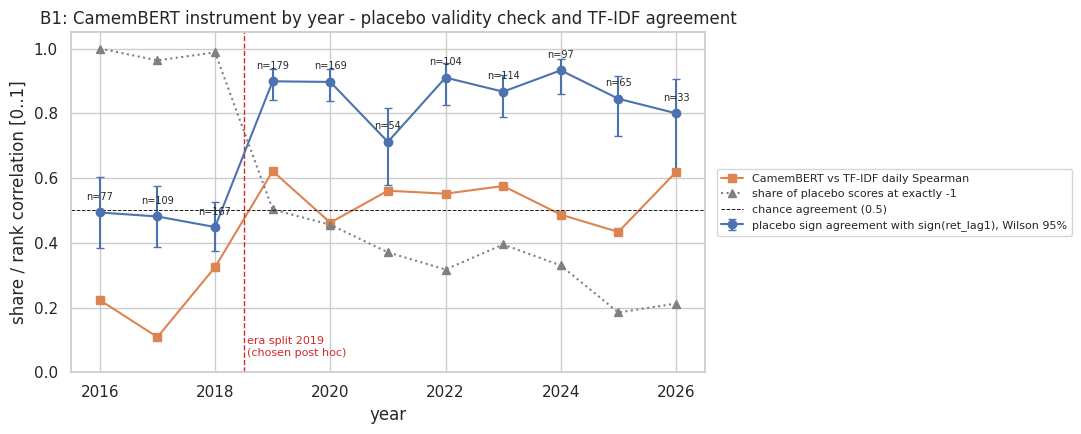

In [5]:
ERA_CUT = 2019   # CHOSEN POST HOC after inspecting the B1 table above
ERA = pd.Series(np.where(YEAR < ERA_CUT, "2016-18", "2019+"), index=df.index)   # only used on has_sent == 1 rows (2016+)
ERAS = ["2016-18", "2019+"]

fig, ax = plt.subplots(figsize=(11, 4.5))
yerr = np.vstack([b1.sign_agreement - b1.agree_lo, b1.agree_hi - b1.sign_agreement])
ax.errorbar(b1.index, b1.sign_agreement, yerr=yerr, marker="o", capsize=3, label="placebo sign agreement with sign(ret_lag1), Wilson 95%")
ax.plot(b1.index, b1.camembert_tfidf_spearman, marker="s", label="CamemBERT vs TF-IDF daily Spearman")
ax.plot(b1.index, b1.share_m1, marker="^", ls=":", color="grey", label="share of placebo scores at exactly -1")
ax.axhline(0.5, color="k", lw=0.7, ls="--", label="chance agreement (0.5)")
ax.axvline(ERA_CUT - 0.5, color="tab:red", lw=1, ls="--")
ax.text(ERA_CUT - 0.45, 0.05, "era split 2019\n(chosen post hoc)", color="tab:red", fontsize=8)
for y, r in b1.iterrows():
    ax.annotate(f"n={int(r.placebo_n)}", (y, r.sign_agreement), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=7)
ax.set(title="B1: CamemBERT instrument by year - placebo validity check and TF-IDF agreement",
       xlabel="year", ylabel="share / rank correlation [0..1]", ylim=(0, 1.05))
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
save(fig, "b1_instrument_by_year")

In [6]:
TARGETS = ["ret_lag3", "ret_lag2", "ret_lag1", "ret_lag0", "ret_next"]
ARMS6 = dict(ARMS, orthogonal_ORPHAN=("sent_resid_lag1", "has_sent_lag1"))

def profile(rowmask=None, arms=ARMS6):
    out = []
    for arm, (sc, flag) in arms.items():
        m = df[flag] == 1
        if rowmask is not None:
            m &= rowmask
        sub = df[m]
        for tcol in TARGETS:
            p = sub[[sc, tcol]].dropna()
            constant = p[sc].nunique() < 2
            out.append(dict(arm=arm, target=tcol, n=len(p),
                            pearson=np.nan if constant else p[sc].corr(p[tcol]),
                            spearman=np.nan if constant else p[sc].corr(p[tcol], method="spearman"),
                            p_naive=np.nan if constant else stats.pearsonr(p[sc], p[tcol])[1]))
    return pd.DataFrame(out)

era_prof = pd.concat({e: profile(ERA == e) for e in ERAS}, names=["era"]).reset_index(level=0)
_pl0 = df.loc[(df.has_sent_price_only_lag1 == 1) & (ERA == "2016-18"), "sent_mean_price_only_lag1"]
PL0_M1, PL0_N = int((_pl0 == -1).sum()), len(_pl0)
PL0_NOTE = f"2016-18 placebo input near-constant ({PL0_M1}/{PL0_N} = -1): its correlations are uninformative"
print("Echo profile per era, each arm on its own has_sent==1 rows. Pearson (n in second table).")
print("Era split 2016-18 / 2019+ CHOSEN POST HOC after inspecting the B1 table.")
print(PL0_NOTE + ".")
print("ret_lag1 = session the headlines describe (validity); ret_next = prediction target (descriptive only).")
print(era_prof.pivot_table(index=["era", "arm"], columns="target", values="pearson")[TARGETS].to_string())
print()
print(era_prof.pivot_table(index=["era", "arm"], columns="target", values="n")[TARGETS].to_string())

Echo profile per era, each arm on its own has_sent==1 rows. Pearson (n in second table).
Era split 2016-18 / 2019+ CHOSEN POST HOC after inspecting the B1 table.
2016-18 placebo input near-constant (347/353 = -1): its correlations are uninformative.
ret_lag1 = session the headlines describe (validity); ret_next = prediction target (descriptive only).
target                     ret_lag3  ret_lag2  ret_lag1  ret_lag0  ret_next
era     arm                                                                
2016-18 all                 -0.0044   -0.0192   -0.0212   -0.0307   -0.0007
        ex_price            -0.0020   -0.0071   -0.0293   -0.0206    0.0026
        orthogonal_ORPHAN   -0.0046   -0.0186   -0.0143   -0.0280   -0.0009
        placebo             -0.0835   -0.0596    0.0000   -0.0625    0.0203
2019+   all                  0.0561    0.0795    0.1409    0.0852    0.0612
        ex_price             0.0367    0.0536    0.0656    0.0679    0.0544
        orthogonal_ORPHAN    0.0385    

## §2 Price and return regime (Q1)

**Question:** are close-to-close returns stationary, and is 2014-2026 one regime or several?
**Pitfalls guarded:** returns are the `ret` column only (close-to-close; no `open`, no recomputation from `close`).
The two shaded bands (COVID 2020-03-01..2020-06-30; rally 2025-01-01..end) were **picked by eye after looking at
the price chart**. They are not estimated break dates, and the sub-sample unit-root tests at those dates are run at
dates chosen after looking. Everything in this section is descriptive; no break is inferred.

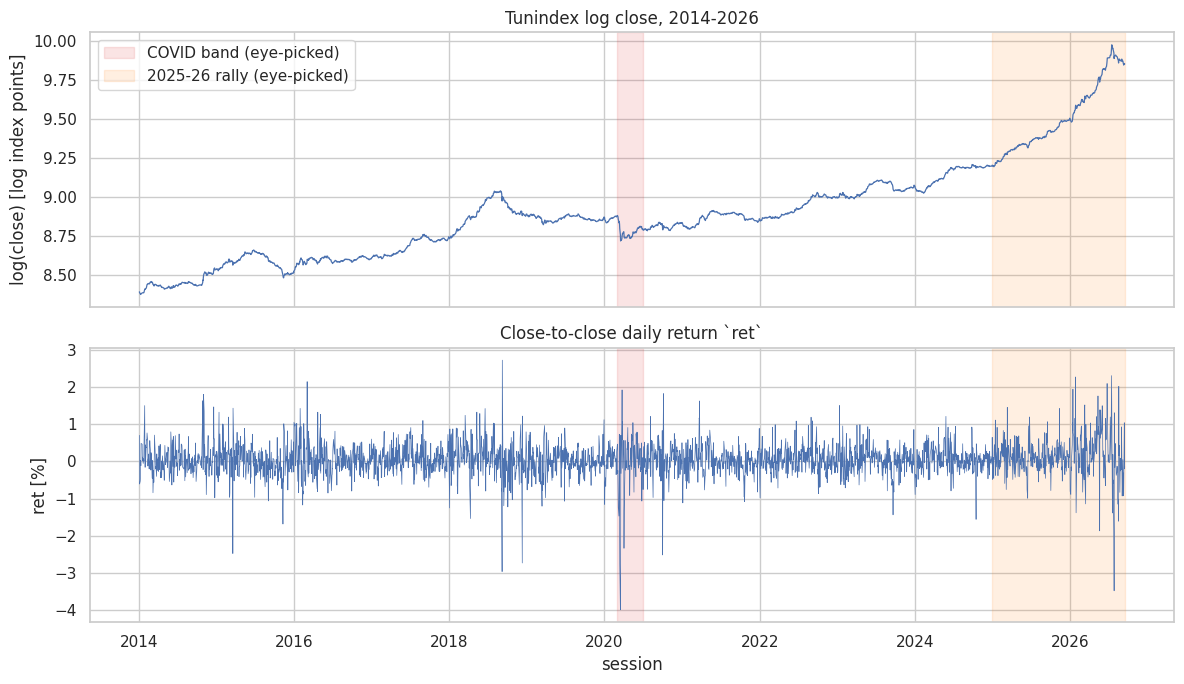

close at last 2024 session: 9953.71 | close at last session: 19054.66


In [7]:
end = df.session.max()
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(df.session, np.log(df.close), lw=0.9)
shade(axes[0], end)
axes[0].set(title="Tunindex log close, 2014-2026", ylabel="log(close) [log index points]")
axes[0].legend(loc="upper left")
axes[1].plot(df.session, df.ret * 100, lw=0.5)
shade(axes[1], end)
axes[1].set(title="Close-to-close daily return `ret`", ylabel="ret [%]", xlabel="session")
save(fig, "s2_price_and_returns")

print("close at last 2024 session:", df.loc[YEAR == 2024, "close"].iloc[-1], "| close at last session:", df.close.iloc[-1])

In [8]:
per_year = df.groupby(YEAR).agg(
    n=("ret", "size"), mean=("ret", "mean"), sd=("ret", "std"),
    skew=("ret", "skew"), kurt=("ret", lambda s: s.kurt()),
    share_zero_phantom=("ret", lambda s: (s == 0).mean()), mean_range_pct=("range_pct", "mean"))
per_year.index.name = "year"
print("Per-year distribution of ret (kurt = excess kurtosis; share_zero_phantom = ret == 0 rows, all copied-OHLC rows, B2):")
print(per_year.to_string())

Per-year distribution of ret (kurt = excess kurtosis; share_zero_phantom = ret == 0 rows, all copied-OHLC rows, B2):
        n    mean     sd    skew    kurt  share_zero_phantom  mean_range_pct
year                                                                        
2014  248  0.0006 0.0041  1.2549  3.4839              0.0000          0.0055
2015  255 -0.0000 0.0044 -0.6295  4.8743              0.0196          0.0063
2016  250  0.0003 0.0042  0.8182  2.7414              0.0080          0.0057
2017  250  0.0005 0.0031  0.3732  0.2312              0.0080          0.0050
2018  249  0.0006 0.0058 -0.7491  5.8909              0.0000          0.0072
2019  249 -0.0001 0.0035 -0.1089  0.9875              0.0000          0.0062
2020  256 -0.0001 0.0065 -2.3451 11.9235              0.0312          0.0088
2021  248  0.0001 0.0035  0.3669  2.3834              0.0040          0.0061
2022  257  0.0006 0.0032  0.3505  1.6117              0.0000          0.0056
2023  251  0.0003 0.0035  0.1101  2.

In [9]:
logc = np.log(df.set_index("session").close)
ret = df.set_index("session").ret
samples = {
    "full 2014-2026":        (None, None),
    "2014-2019 (pre-COVID)": (None, "2019-12-31"),
    "2020-2024":             ("2020-01-01", "2024-12-31"),
    "2025-2026 (rally)":     ("2025-01-01", None),
}
rows = []
for name, (a, b) in samples.items():
    for series_name, s in [("log(close)", logc), ("ret", ret)]:
        x = s.loc[a:b].dropna()
        adf_stat, adf_p = adfuller(x, autolag="AIC")[:2]
        kpss_stat, kpss_p = kpss(x, regression="c", nlags="auto")[:2]
        rows.append(dict(sample=name, series=series_name, n=len(x),
                         adf_stat=adf_stat, adf_p=adf_p, kpss_stat=kpss_stat, kpss_p=kpss_p))
unit_root = pd.DataFrame(rows)
print("ADF (H0: unit root) and KPSS (H0: level-stationary). KPSS p is clipped to [0.01, 0.10] by statsmodels.")
print("Sub-sample boundaries were picked by eye after looking at the chart.")
print(unit_root.to_string(index=False))

ADF (H0: unit root) and KPSS (H0: level-stationary). KPSS p is clipped to [0.01, 0.10] by statsmodels.
Sub-sample boundaries were picked by eye after looking at the chart.
               sample     series    n  adf_stat  adf_p  kpss_stat  kpss_p
       full 2014-2026 log(close) 3179    1.6856 0.9981     6.9840  0.0100
       full 2014-2026        ret 3179   -9.9872 0.0000     0.6137  0.0214
2014-2019 (pre-COVID) log(close) 1501   -1.3584 0.6020     5.1215  0.0100
2014-2019 (pre-COVID)        ret 1501  -10.0418 0.0000     0.1525  0.1000
            2020-2024 log(close) 1260   -0.0116 0.9576     5.3734  0.0100
            2020-2024        ret 1260  -13.2319 0.0000     0.1934  0.1000
    2025-2026 (rally) log(close)  418   -0.1808 0.9408     3.1300  0.0100
    2025-2026 (rally)        ret  418  -14.5480 0.0000     0.1396  0.1000


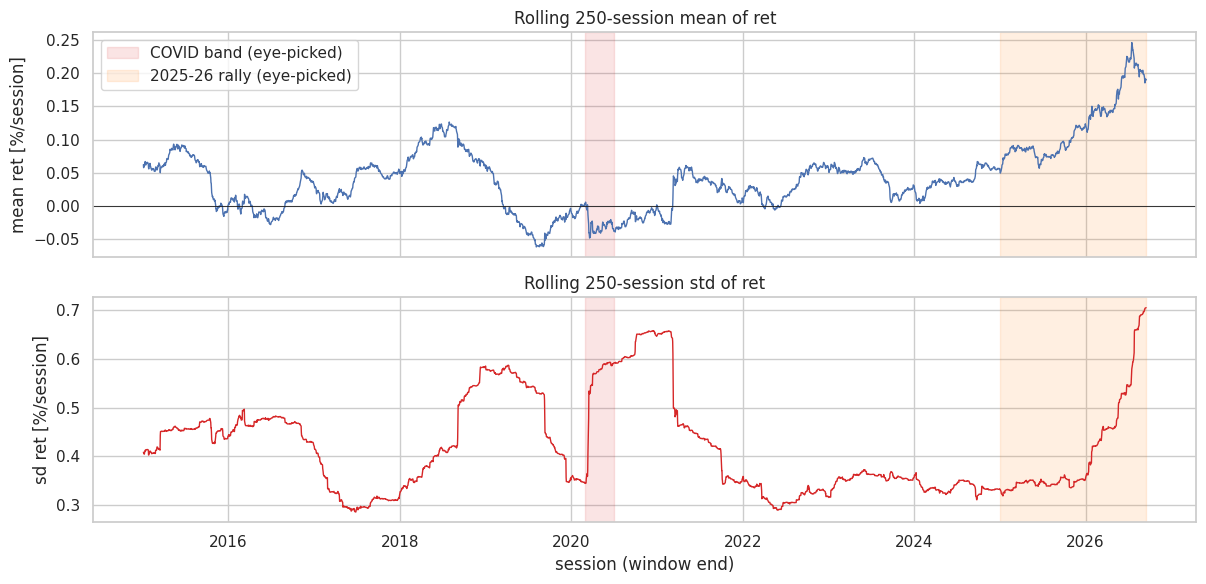

Rolling stats at each year-end (window end):
         roll_mean  roll_sd
session                    
2014           NaN      NaN
2015        0.0000   0.0044
2016        0.0003   0.0042
2017        0.0005   0.0031
2018        0.0006   0.0058
2019       -0.0001   0.0035
2020        0.0000   0.0065
2021        0.0001   0.0035
2022        0.0006   0.0032
2023        0.0003   0.0036
2024        0.0006   0.0033
2025        0.0012   0.0035
2026        0.0019   0.0071


In [10]:
roll = df.set_index("session").ret.rolling(250)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(roll.mean() * 100, lw=1)
axes[0].axhline(0, color="k", lw=0.6)
axes[0].set(title="Rolling 250-session mean of ret", ylabel="mean ret [%/session]")
axes[1].plot(roll.std() * 100, lw=1, color="tab:red")
axes[1].set(title="Rolling 250-session std of ret", ylabel="sd ret [%/session]", xlabel="session (window end)")
for ax in axes:
    shade(ax, df.session.max())
axes[0].legend(loc="upper left")
save(fig, "s2_rolling_mean_sd")
r = pd.DataFrame({"roll_mean": roll.mean(), "roll_sd": roll.std()})
print("Rolling stats at each year-end (window end):")
print(r.groupby(r.index.year).last().to_string())

OLS-CUSUM on ret (constant-mean model): sup|B| = 2.106, p = 0.0003, crit (1/5/10%) = [(1, 1.63), (5, 1.36), (10, 1.22)]
DESCRIPTIVE. The CUSUM of demeaned returns is (approximately) the detrended log price, so this path is the log index
with its average drift removed. Its minimum in 2024 and the climb after it are the 2025-26 drift: p = 0.0003 reflects a CHANGING MEAN (drift), not a volatility break, and it does not date any break.
CUSUM path minimum -2.11 on 2024-02-12


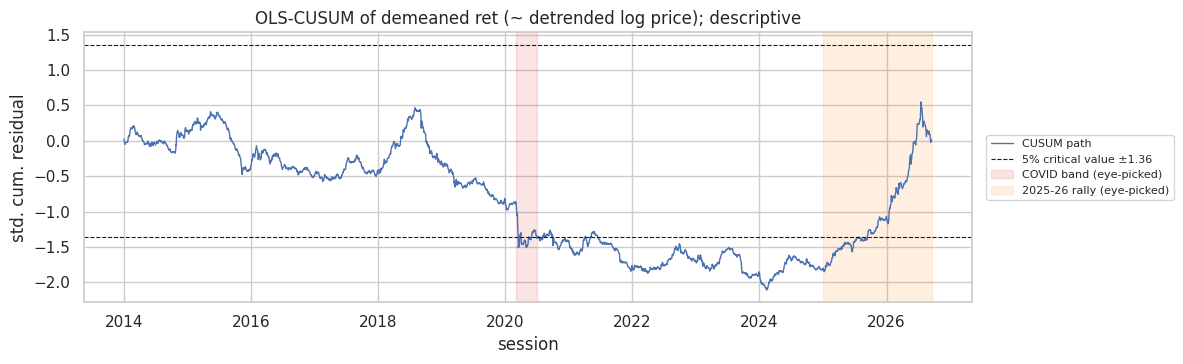

In [11]:
resid = (df.ret - df.ret.mean()).values          # OLS of ret on a constant
sup_b, p_cusum, crit = breaks_cusumolsresid(resid, ddof=1)
print(f"OLS-CUSUM on ret (constant-mean model): sup|B| = {sup_b:.3f}, p = {p_cusum:.4f}, crit (1/5/10%) = {crit}")
print("DESCRIPTIVE. The CUSUM of demeaned returns is (approximately) the detrended log price, so this path is the log index")
print("with its average drift removed. Its minimum in 2024 and the climb after it are the 2025-26 drift: p = "
      f"{p_cusum:.4f} reflects a CHANGING MEAN (drift), not a volatility break, and it does not date any break.")
path = np.cumsum(resid) / (resid.std(ddof=1) * np.sqrt(len(resid)))
print(f"CUSUM path minimum {path.min():.2f} on {df.session.iloc[path.argmin()].date()}")

crit5 = dict(crit)[5]
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(df.session, path, lw=1, label="CUSUM path")
ax.axhline(crit5, color="k", ls="--", lw=0.8, label=f"5% critical value ±{crit5:.2f}")
ax.axhline(-crit5, color="k", ls="--", lw=0.8)
shade(ax, df.session.max())
ax.set(title="OLS-CUSUM of demeaned ret (~ detrended log price); descriptive", ylabel="std. cum. residual", xlabel="session")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
save(fig, "s2_cusum")

## §3 Dependence and volatility clustering (Q2, Q3)

**Question:** how strong are return autocorrelation and volatility clustering, are they stable across sub-periods,
and is the next-session up/down base rate drifting?
**Pitfalls guarded:** `ret_next[i] == ret[i+1]` (asserted in §1), so any `ret`/`ret_next` correlation is ACF(1)
and is called that. Returns come from the `ret` column, not a new formula. The rolling ACF(1) below uses the existing
`ret_lag1` column rather than a shift. ACF on return *levels* is not directional predictability, and rolling ACF(1) is
leveraged by a handful of extreme days (see caption and B3).

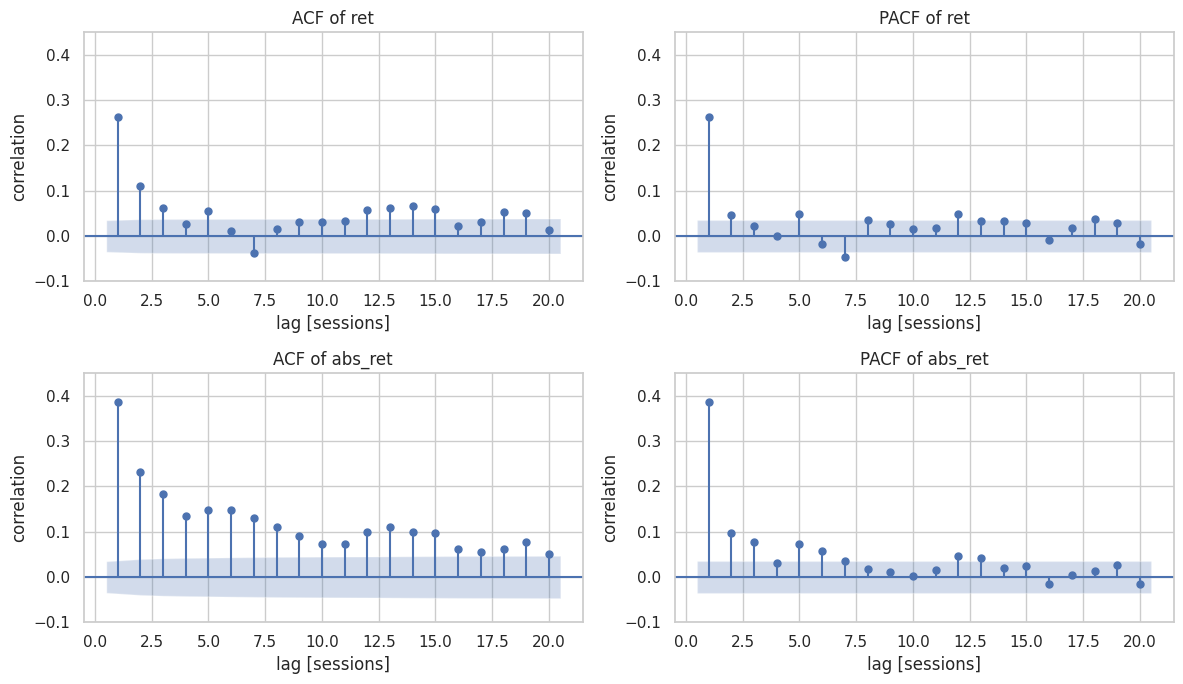

Full sample: ACF(1) ret = +0.2628, ACF(1) abs_ret = +0.3869
     acf_ret  pacf_ret  acf_abs_ret  pacf_abs_ret
lag                                              
1     0.2628    0.2628       0.3869        0.3869
2     0.1112    0.0453       0.2315        0.0962
3     0.0611    0.0229       0.1830        0.0769
4     0.0259    0.0002       0.1352        0.0320
5     0.0562    0.0482       0.1477        0.0738
6     0.0107   -0.0183       0.1471        0.0571
7    -0.0369   -0.0461       0.1311        0.0360
8     0.0162    0.0364       0.1100        0.0183
9     0.0307    0.0262       0.0913        0.0117
10    0.0319    0.0160       0.0718        0.0014
11    0.0331    0.0174       0.0722        0.0160
12    0.0573    0.0483       0.0984        0.0472
13    0.0620    0.0320       0.1103        0.0423
14    0.0667    0.0329       0.0990        0.0192
15    0.0595    0.0282       0.0962        0.0243
16    0.0210   -0.0098       0.0617       -0.0149
17    0.0303    0.0167       0.0561     

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for i, c in enumerate(["ret", "abs_ret"]):
    plot_acf(df[c], lags=20, zero=False, ax=axes[i, 0], title=f"ACF of {c}")
    plot_pacf(df[c], lags=20, zero=False, ax=axes[i, 1], title=f"PACF of {c}", method="ywm")
    for ax in axes[i]:
        ax.set(xlabel="lag [sessions]", ylabel="correlation", ylim=(-0.1, 0.45))
save(fig, "s3_acf_pacf")

acf_tab = pd.DataFrame({
    "acf_ret": acf(df.ret, nlags=20)[1:], "pacf_ret": pacf(df.ret, nlags=20, method="ywm")[1:],
    "acf_abs_ret": acf(df.abs_ret, nlags=20)[1:], "pacf_abs_ret": pacf(df.abs_ret, nlags=20, method="ywm")[1:],
}, index=pd.RangeIndex(1, 21, name="lag"))
print(f"Full sample: ACF(1) ret = {ACF1_RET:+.4f}, ACF(1) abs_ret = {ACF1_ABS:+.4f}")
print(acf_tab.to_string())

In [13]:
lb = pd.concat({c: acorr_ljungbox(df[c], lags=[5, 10, 20]) for c in ["ret", "abs_ret"]}, names=["series", "lag"])
print("Ljung-Box (H0: no autocorrelation up to lag):")
print(lb.to_string())
print()
for nl in [5, 10]:
    lm, lm_p, f, f_p = het_arch(df.ret, nlags=nl)
    print(f"ARCH-LM on ret, {nl} lags: LM = {lm:.1f}, p = {lm_p:.2e}")

Ljung-Box (H0: no autocorrelation up to lag):
              lb_stat  lb_pvalue
series  lag                     
ret     5    283.1962     0.0000
        10   295.0071     0.0000
        20   369.0886     0.0000
abs_ret 5    881.2944     0.0000
        10  1086.6560     0.0000
        20  1295.7189     0.0000

ARCH-LM on ret, 5 lags: LM = 788.7, p = 3.21e-168
ARCH-LM on ret, 10 lags: LM = 794.5, p = 3.13e-164


ACF(1) within each calendar year:
            n  acf1_ret  acf1_abs_ret
year                                 
2014 248.0000    0.3859        0.3887
2015 255.0000    0.1154        0.1922
2016 250.0000    0.1950        0.2164
2017 250.0000    0.2028        0.0273
2018 249.0000    0.0981        0.3758
2019 249.0000    0.1538        0.2390
2020 256.0000    0.4315        0.5341
2021 248.0000    0.2664        0.2982
2022 257.0000    0.1509        0.0651
2023 251.0000    0.2105        0.1808
2024 248.0000    0.1042        0.1142
2025 245.0000    0.1331        0.1539
2026 173.0000    0.3762        0.4374


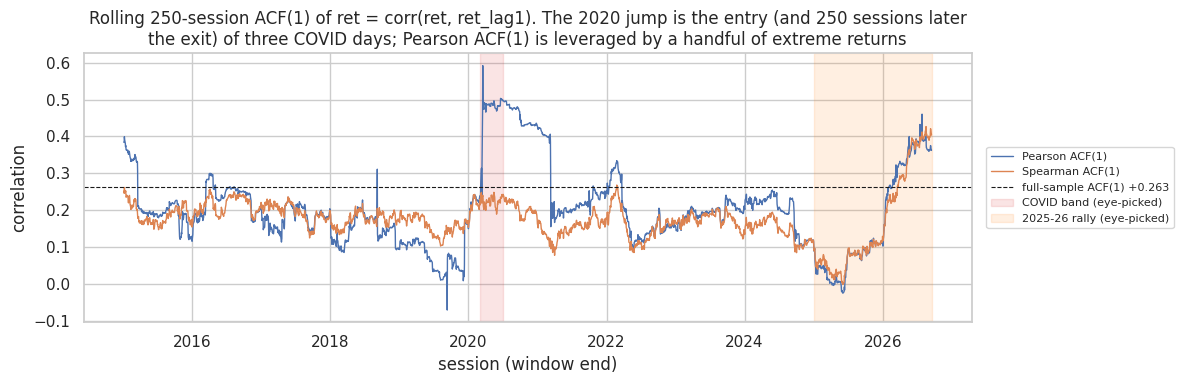

Largest |ret| days inside the COVID band (drive the step in the Pearson line):
   session     ret
2020-03-16 -0.0398
2020-03-17 -0.0383
2020-03-13 -0.0277
         pearson  spearman
session                   
2014         NaN       NaN
2015      0.1152    0.1539
2016      0.2139    0.2207
2017      0.2035    0.1992
2018      0.0955    0.1713
2019      0.1523    0.1575
2020      0.4274    0.1632
2021      0.2455    0.1753
2022      0.1565    0.1703
2023      0.2109    0.1467
2024      0.1148    0.1120
2025      0.1195    0.1285
2026      0.3628    0.4054


In [14]:
acf1_year = df.groupby(YEAR).apply(lambda g: pd.Series({
    "n": len(g), "acf1_ret": acf(g.ret, nlags=1)[1], "acf1_abs_ret": acf(g.abs_ret, nlags=1)[1]}), include_groups=False)
acf1_year.index.name = "year"
print("ACF(1) within each calendar year:")
print(acf1_year.to_string())

# rolling ACF(1): corr(ret, ret_lag1) over 250 sessions, ret_lag1 used as-is; plus a rolling Spearman
W = 250
rolling_acf1 = df.set_index("session").ret.rolling(W).corr(df.set_index("session").ret_lag1)
r_, rl_ = df.ret.values, df.ret_lag1.values
rs = np.full(len(df), np.nan)
for i in range(W - 1, len(df)):
    rs[i] = stats.spearmanr(r_[i - W + 1:i + 1], rl_[i - W + 1:i + 1])[0]
rolling_spear = pd.Series(rs, index=df.session)

top_covid = df[(df.session >= COVID[0]) & (df.session <= COVID[1])].assign(a=lambda d: d.ret.abs()).nlargest(3, "a")[["session", "ret"]]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rolling_acf1, lw=1, label="Pearson ACF(1)")
ax.plot(rolling_spear, lw=1, label="Spearman ACF(1)")
ax.axhline(ACF1_RET, color="k", ls="--", lw=0.8, label=f"full-sample ACF(1) {ACF1_RET:+.3f}")
shade(ax, df.session.max())
ax.set(title="Rolling 250-session ACF(1) of ret = corr(ret, ret_lag1). The 2020 jump is the entry (and 250 sessions later\n"
             "the exit) of three COVID days; Pearson ACF(1) is leveraged by a handful of extreme returns",
       ylabel="correlation", xlabel="session (window end)")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
save(fig, "s3_rolling_acf1")
print("Largest |ret| days inside the COVID band (drive the step in the Pearson line):")
print(top_covid.to_string(index=False))
print(pd.DataFrame({"pearson": rolling_acf1, "spearman": rolling_spear}).groupby(lambda d: d.year).last().to_string())

Next-session direction base rate by year (row year; target is session i+1).
ret_next == 0 rows are NOT flat markets: the next row is a phantom (OHLC copied from the previous row), see B2.
        n  up_share  up_lo  up_hi  down_share  n_target_on_phantom
year                                                              
2014  248    0.5161 0.4542 0.5776      0.4839                    0
2015  255    0.4941 0.4333 0.5551      0.4863                    5
2016  250    0.5040 0.4424 0.5654      0.4880                    2
2017  250    0.5200 0.4582 0.5812      0.4720                    2
2018  249    0.5703 0.5082 0.6302      0.4297                    0
2019  249    0.4900 0.4285 0.5517      0.5060                    1
2020  256    0.5547 0.4934 0.6143      0.4180                    7
2021  248    0.5040 0.4422 0.5657      0.4919                    1
2022  257    0.5447 0.4837 0.6045      0.4553                    0
2023  251    0.5498 0.4880 0.6101      0.4502                    0
2024  24

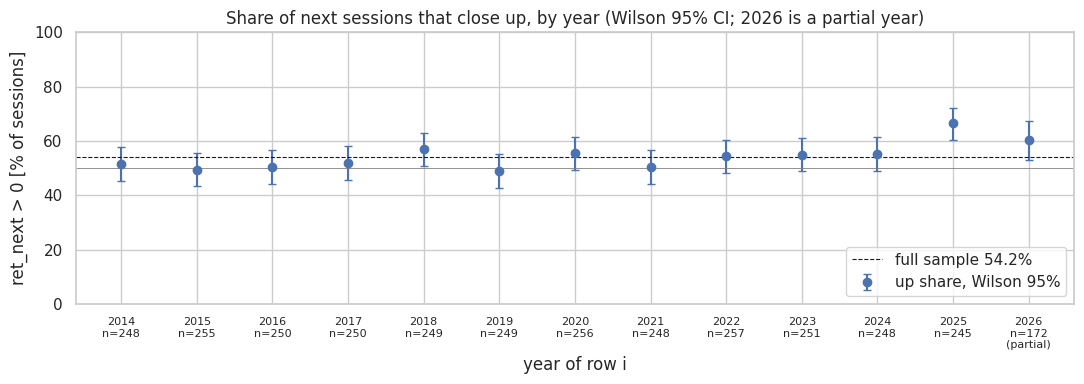

In [15]:
t = df.dropna(subset=["ret_next"]).copy()
rows = []
for y, g in t.groupby(t.session.dt.year):
    k, n = int((g.ret_next > 0).sum()), len(g)
    lo, hi = wilson(k, n)
    rows.append(dict(year=y, n=n, up_share=k / n, up_lo=lo, up_hi=hi, down_share=(g.ret_next < 0).mean(),
                     n_target_on_phantom=int((g.ret_next == 0).sum())))
base = pd.DataFrame(rows).set_index("year")
print("Next-session direction base rate by year (row year; target is session i+1).")
print("ret_next == 0 rows are NOT flat markets: the next row is a phantom (OHLC copied from the previous row), see B2.")
print(base.to_string())
print(f"\nFull sample: up {UP_RATE:.4f}; {N_ZERO_TARGET} targets fall on phantom rows")
wf = t.iloc[500:]
print(f"Rows 501..end ({len(wf)} rows, the walk-forward prediction span with min_train=500, "
      f"{wf.session.iloc[0].date()}..{wf.session.iloc[-1].date()}): up share = {(wf.ret_next > 0).mean():.4f} "
      f"(docs quote the always-up constant as 0.5493 over 2,678 predictions); phantom targets in span: {int((wf.ret_next == 0).sum())}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.errorbar(base.index, base.up_share * 100, yerr=[(base.up_share - base.up_lo) * 100, (base.up_hi - base.up_share) * 100],
            fmt="o", capsize=3, label="up share, Wilson 95%")
ax.axhline(UP_RATE * 100, color="k", ls="--", lw=0.8, label=f"full sample {UP_RATE:.1%}")
ax.axhline(50, color="grey", lw=0.6)
ax.set_xticks(base.index)
ax.set_xticklabels([f"{y}\nn={n}" + ("\n(partial)" if y == 2026 else "") for y, n in base.n.items()], fontsize=8)
ax.set(title="Share of next sessions that close up, by year (Wilson 95% CI; 2026 is a partial year)",
       ylabel="ret_next > 0 [% of sessions]", xlabel="year of row i", ylim=(0, 100))
ax.legend(loc="lower right")
save(fig, "s3_base_rate_by_year")

## §4 Coverage timeline (Q4, Q5)

**Question:** how does news and sentiment coverage evolve, and does the corpus composition drift?
**Pitfalls guarded:** the 2014-15 zeros are **unscored, not neutral**: `has_sent_lag1 = 0` <=> `sent_n = 0` <=> the
503 sessions 2014-01-02..2015-12-31 (asserted in §1). Composition drift (international share rising, price-report
share falling) is a **confound on any time-pooled sentiment statistic**. The price-report share is shown both
corpus-level (sum of price reports / sum of headlines) and as the per-session mean, labelled; the stale 10% figure is not used.
The vertical line marks the end of the first walk-forward training window (row 500). Source mix over time cannot be
studied from this frame: it has only `n_sources`, no per-source counts.

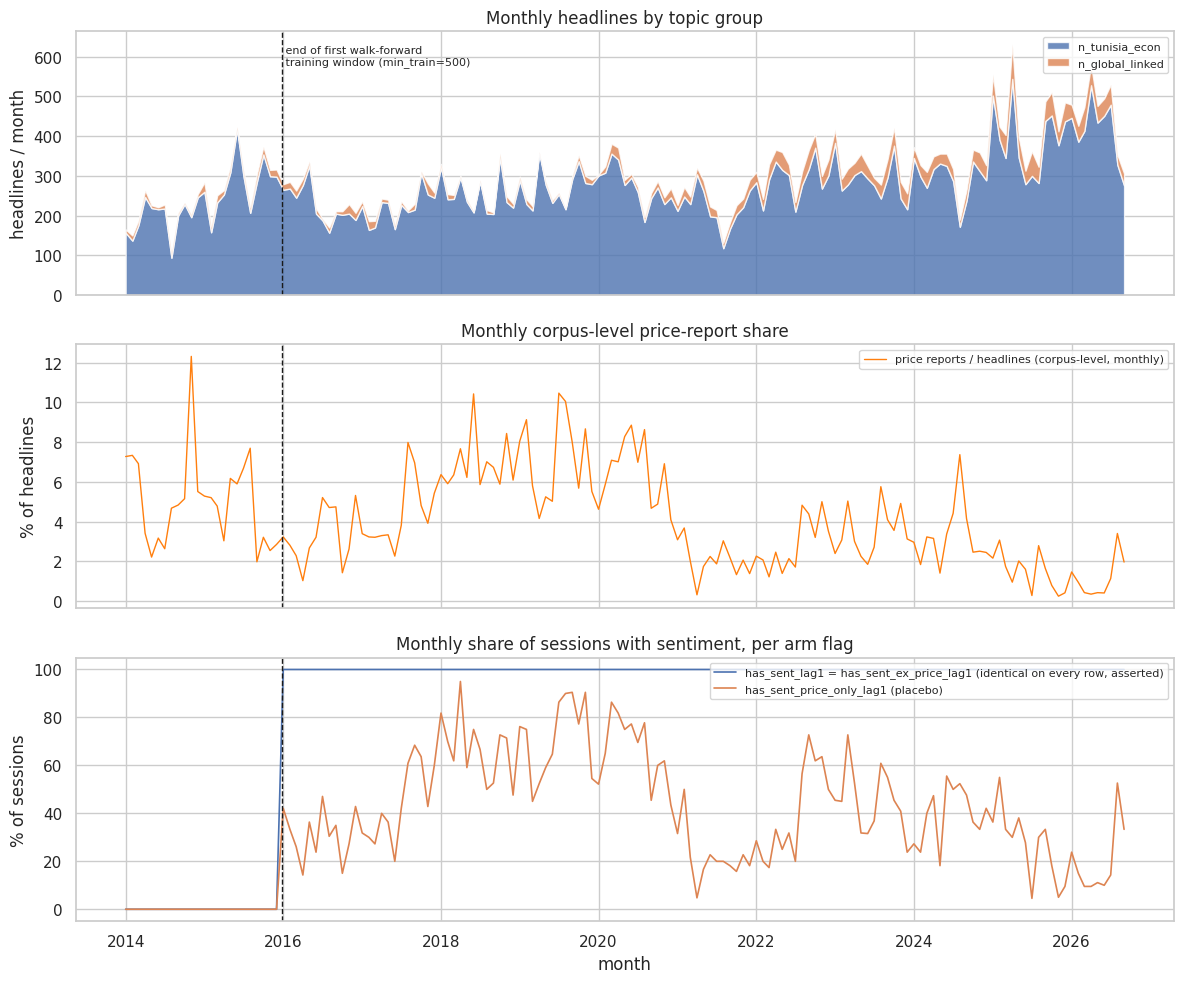

n_tunisia_econ + n_global_linked == n_headlines on every row: True
Monthly corpus-level price-report share, yearly summary of the monthly values:
          mean    min    max
session                     
2014    0.0545 0.0221 0.1232
2015    0.0461 0.0197 0.0769
2016    0.0327 0.0102 0.0531
2017    0.0430 0.0226 0.0798
2018    0.0691 0.0586 0.1043
2019    0.0715 0.0416 0.1047
2020    0.0649 0.0409 0.0885
2021    0.0208 0.0031 0.0368
2022    0.0285 0.0122 0.0500
2023    0.0348 0.0185 0.0576
2024    0.0327 0.0140 0.0737
2025    0.0147 0.0024 0.0307
2026    0.0117 0.0035 0.0340


In [16]:
TRAIN_END = df.session.iloc[499]
assert TRAIN_END == pd.Timestamp("2015-12-28")
m = df.set_index("session").resample("MS")
cnt = m[["n_tunisia_econ", "n_global_linked", "n_price_reports", "n_headlines"]].sum()
cnt["price_share_corpus"] = cnt.n_price_reports / cnt.n_headlines
flags = m[["has_sent_lag1", "has_sent_price_only_lag1"]].mean()

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
axes[0].stackplot(cnt.index, cnt.n_tunisia_econ, cnt.n_global_linked, labels=["n_tunisia_econ", "n_global_linked"], alpha=0.8)
axes[0].set(title="Monthly headlines by topic group", ylabel="headlines / month")
axes[1].plot(cnt.index, cnt.price_share_corpus * 100, lw=1, color="tab:orange", label="price reports / headlines (corpus-level, monthly)")
axes[1].set(title="Monthly corpus-level price-report share", ylabel="% of headlines")
axes[2].plot(flags.index, flags.has_sent_lag1 * 100, lw=1.2, label="has_sent_lag1 = has_sent_ex_price_lag1 (identical on every row, asserted)")
axes[2].plot(flags.index, flags.has_sent_price_only_lag1 * 100, lw=1.2, label="has_sent_price_only_lag1 (placebo)")
axes[2].set(title="Monthly share of sessions with sentiment, per arm flag", ylabel="% of sessions", xlabel="month")
for ax in axes:
    ax.axvline(TRAIN_END, color="k", ls="--", lw=1)
    ax.legend(loc="upper right", fontsize=8)
axes[0].text(TRAIN_END, axes[0].get_ylim()[1] * 0.95, " end of first walk-forward\n training window (min_train=500)", va="top", fontsize=8)
save(fig, "s4_coverage_timeline")
print("n_tunisia_econ + n_global_linked == n_headlines on every row:",
      bool((df.n_tunisia_econ + df.n_global_linked == df.n_headlines).all()))
print("Monthly corpus-level price-report share, yearly summary of the monthly values:")
print(cnt.price_share_corpus.groupby(cnt.index.year).describe()[["mean", "min", "max"]].to_string())

In [17]:
g = df.groupby(YEAR)
cov = pd.DataFrame({
    "sessions": g.size(),
    "median_n_headlines": g.n_headlines.median(),
    "headlines": g.n_headlines.sum(),
    "n_global_linked": g.n_global_linked.sum(),
    "global_share_corpus": g.n_global_linked.sum() / g.n_headlines.sum(),
    "scored_share_corpus (sent_n/n_headlines)": g.sent_n.sum() / g.n_headlines.sum(),
    "has_sent_lag1 (= ex_price)": g.has_sent_lag1.mean(),
    "has_sent_price_only_lag1": g.has_sent_price_only_lag1.mean(),
    "price_share_corpus": g.n_price_reports.sum() / g.n_headlines.sum(),
    "price_share_mean_per_session": g.price_report_share.mean(),
})
cov.index.name = "year"
print("Per-year coverage and composition ('_corpus' = sum/sum; 'mean_per_session' = mean of the daily share):")
print(cov.T.to_string())
print(f"\nWhole frame: price reports {df.n_price_reports.sum()} / {df.n_headlines.sum()} headlines = "
      f"{df.n_price_reports.sum() / df.n_headlines.sum():.2%} corpus-level; per-session mean = {df.price_report_share.mean():.2%}")

scored = df[df.has_sent_lag1 == 1]
mismatch = scored[scored.sent_n != scored.n_headlines]
assert len(mismatch) == 1, mismatch
print(f"sent_n == n_headlines on {len(scored) - len(mismatch)} of {len(scored)} scored sessions; the single exception:")
print(mismatch[["session", "sent_n", "n_headlines"]].to_string(index=False))

Per-year coverage and composition ('_corpus' = sum/sum; 'mean_per_session' = mean of the daily share):
year                                          2014      2015      2016      2017      2018      2019      2020      2021      2022      2023      2024      2025      2026
sessions                                  248.0000  255.0000  250.0000  250.0000  249.0000  249.0000  256.0000  248.0000  257.0000  251.0000  248.0000  245.0000  173.0000
median_n_headlines                          9.0000   13.0000   11.0000   11.0000   11.0000   13.0000   13.0000   11.0000   14.0000   14.0000   14.0000   19.0000   20.0000
headlines                                2446.0000 3564.0000 2895.0000 2799.0000 3136.0000 3368.0000 3502.0000 2867.0000 3892.0000 3921.0000 3894.0000 5305.0000 4117.0000
n_global_linked                           111.0000  191.0000  163.0000  153.0000   95.0000  108.0000  190.0000  246.0000  407.0000  440.0000  374.0000  612.0000  376.0000
global_share_corpus                       

First walk-forward training window: rows 1..500 = 2014-01-02..2015-12-28
Share of those 500 rows with has_sent_lag1 = 1: 0.0 | distinct values of sent_mean_lag1 in them: [0.]
=> the first H1 fit sees every sentiment feature as a constant 0-fill, and has_sent_lag1 is a 2016-onward step dummy
   in every expanding window. Handed to the statistician (§9); not ruled on here.

n_sources distribution (sessions per number of distinct sources):
n_sources
1      40
2     560
3    1921
4     484
5     154
6      15
7       5


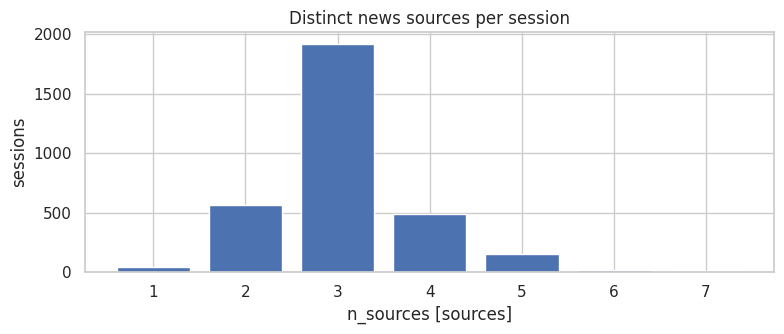

In [18]:
print(f"First walk-forward training window: rows 1..500 = {df.session.iloc[0].date()}..{TRAIN_END.date()}")
w = df.iloc[:500]
print("Share of those 500 rows with has_sent_lag1 = 1:", w.has_sent_lag1.mean(),
      "| distinct values of sent_mean_lag1 in them:", w.sent_mean_lag1.unique())
print("=> the first H1 fit sees every sentiment feature as a constant 0-fill, and has_sent_lag1 is a 2016-onward step dummy")
print("   in every expanding window. Handed to the statistician (§9); not ruled on here.")

ns = df.n_sources.value_counts().sort_index()
print("\nn_sources distribution (sessions per number of distinct sources):")
print(ns.to_string())
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(ns.index, ns.values)
ax.set(title="Distinct news sources per session", xlabel="n_sources [sources]", ylabel="sessions")
save(fig, "s4_n_sources")

## §5 Sentiment distributions per arm and per era (Q6, Q8)

**Question:** what do the sentiment features look like per arm, and do the CamemBERT and TF-IDF instruments agree?
**Pitfalls guarded:** each arm is filtered on its **own** `has_sent_*_lag1 == 1` (placebo covers 1,168 sessions, not
2,676), and everything is split by era (2016-18 / 2019+, chosen post hoc in B1) because the instrument differs across
it. Share columns are ratios of small counts, so they pile up on 1/2, 1/3, 1/4; they are shown as ECDFs rather than
histograms to avoid binning artefacts. The placebo is essentially three-valued (most placebo sessions rest on one
headline), so it is drawn as bar counts. CamemBERT and TF-IDF are shown side by side and correlated, never pooled.
`sent_resid_*` are orphan columns (architecture §7.1): plotted, marked, not interpreted.

80% of placebo sessions rest on exactly 1 price-report headline (sent_n_price_only == 1)


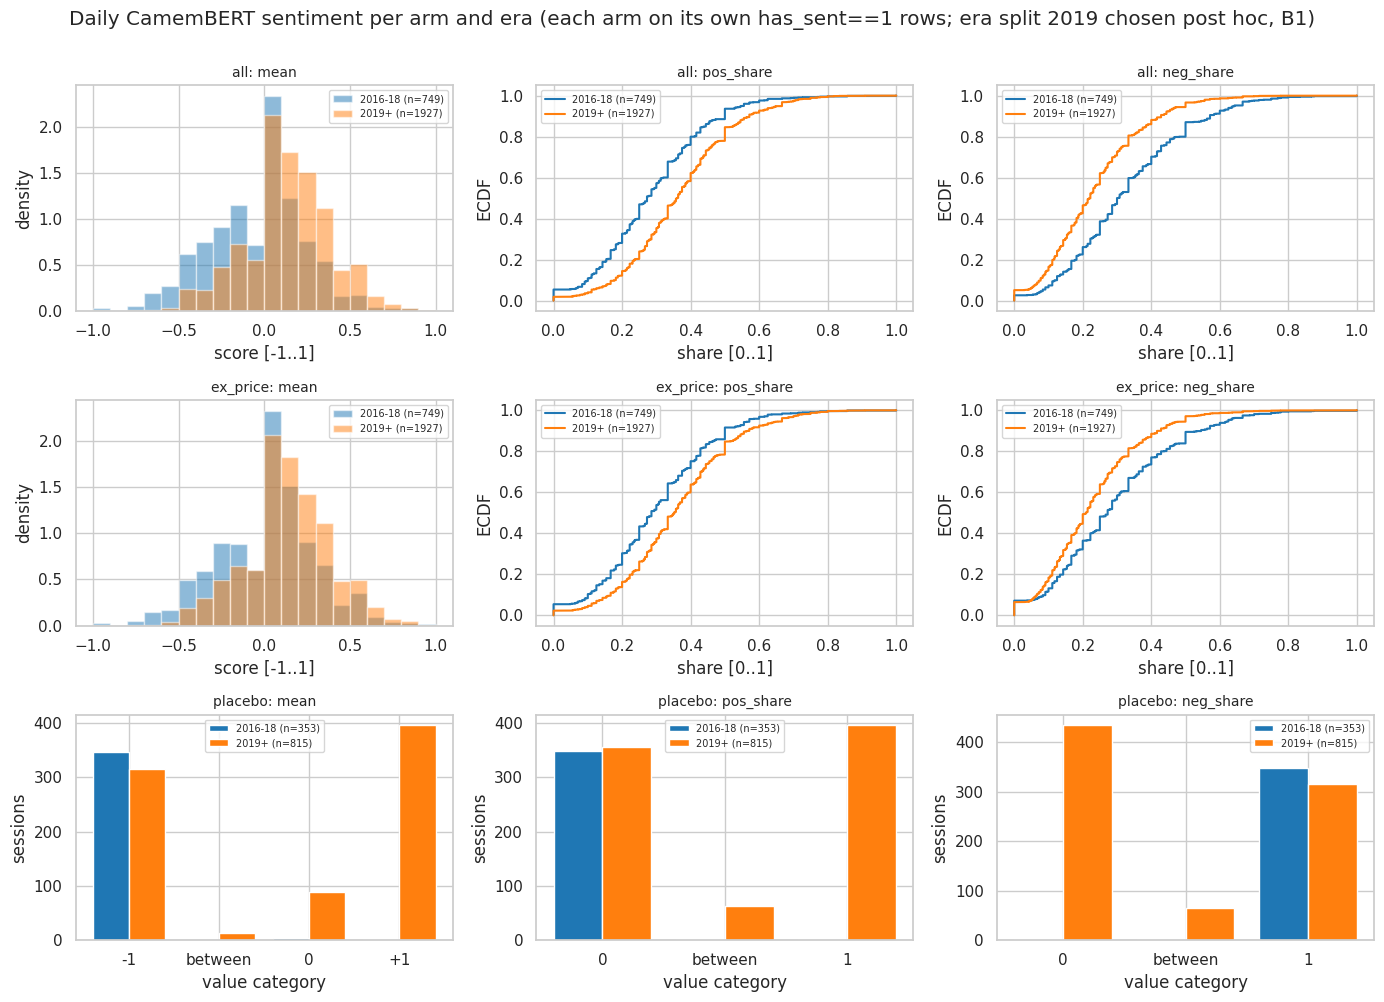

     arm     era                         column    n    mean     sd  median  share_at_minus1  share_at_0  share_at_1
     all 2016-18                 sent_mean_lag1  749 -0.0430 0.2844  0.0000           0.0027      0.1669      0.0013
     all   2019+                 sent_mean_lag1 1927  0.1317 0.2497  0.1429           0.0005      0.1043      0.0005
     all 2016-18            sent_pos_share_lag1  749  0.2858 0.1554  0.2727           0.0000      0.0547      0.0013
     all   2019+            sent_pos_share_lag1 1927  0.3662 0.1572  0.3600           0.0000      0.0192      0.0005
     all 2016-18            sent_neg_share_lag1  749  0.3288 0.1741  0.3000           0.0000      0.0267      0.0027
     all   2019+            sent_neg_share_lag1 1927  0.2345 0.1399  0.2222           0.0000      0.0519      0.0005
ex_price 2016-18        sent_mean_ex_price_lag1  749  0.0092 0.2914  0.0000           0.0027      0.1722      0.0013
ex_price   2019+        sent_mean_ex_price_lag1 1927  0.1336 0.2

In [19]:
single = (df.loc[df.has_sent_price_only_lag1 == 1, "sent_n_price_only"] == 1).mean()
print(f"{single:.0%} of placebo sessions rest on exactly 1 price-report headline (sent_n_price_only == 1)")

def cat_mean(x):
    return pd.Categorical(np.select([x == -1, x == 0, x == 1], ["-1", "0", "+1"], "between"), ["-1", "between", "0", "+1"])
def cat_share(x):
    return pd.Categorical(np.select([x == 0, x == 1], ["0", "1"], "between"), ["0", "between", "1"])

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
rows = []
colors = dict(zip(ERAS, ["tab:blue", "tab:orange"]))
for i, arm in enumerate(ARMS):
    suffix = {"all": "", "ex_price": "_ex_price", "placebo": "_price_only"}[arm]
    flag = ARMS[arm][1]
    for j, s in enumerate(["mean", "pos_share", "neg_share"]):
        c = f"sent_{s}{suffix}_lag1"
        ax = axes[i, j]
        for e in ERAS:
            x = df.loc[(df[flag] == 1) & (ERA == e), c]
            rows.append(dict(arm=arm, era=e, column=c, n=len(x), mean=x.mean(), sd=x.std(), median=x.median(),
                             share_at_minus1=(x == -1).mean(), share_at_0=(x == 0).mean(), share_at_1=(x == 1).mean()))
            if arm == "placebo":
                vc = pd.Series(cat_mean(x) if s == "mean" else cat_share(x)).value_counts(sort=False)
                off = -0.2 if e == ERAS[0] else 0.2
                ax.bar(np.arange(len(vc)) + off, vc.values, width=0.4, color=colors[e], label=f"{e} (n={len(x)})")
                ax.set_xticks(range(len(vc)), vc.index)
                ax.set(ylabel="sessions", xlabel="value category")
            elif s == "mean":
                ax.hist(x, bins=np.linspace(-1, 1, 21), density=True, alpha=0.5, color=colors[e], label=f"{e} (n={len(x)})")
                ax.set(ylabel="density", xlabel="score [-1..1]")
            else:
                xs = np.sort(x.values)
                ax.step(xs, np.arange(1, len(xs) + 1) / len(xs), where="post", color=colors[e], label=f"{e} (n={len(x)})")
                ax.set(ylabel="ECDF", xlabel="share [0..1]")
        ax.set_title(f"{arm}: {s}", fontsize=10)
        ax.legend(fontsize=7)
fig.suptitle("Daily CamemBERT sentiment per arm and era (each arm on its own has_sent==1 rows; era split 2019 chosen post hoc, B1)", y=1.0)
save(fig, "s5_hist_per_arm")
print(pd.DataFrame(rows).to_string(index=False))

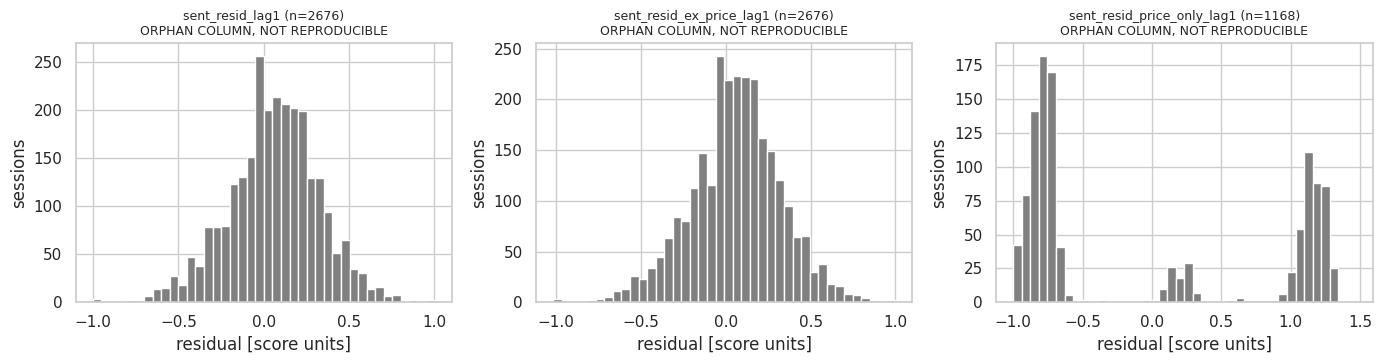

Orphan columns (architecture §7.1): shown for completeness, not interpreted.
                    column    n    mean     sd
           sent_resid_lag1 2676  0.0602 0.2644
  sent_resid_ex_price_lag1 2676  0.0572 0.2662
sent_resid_price_only_lag1 1168 -0.0386 0.9127


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
rows = []
for ax, (arm, (_, flag)) in zip(axes, ARMS.items()):
    x = df.loc[df[flag] == 1, RESID[arm]]
    ax.hist(x, bins=40, color="grey")
    ax.set_title(f"{RESID[arm]} (n={len(x)})\nORPHAN COLUMN, NOT REPRODUCIBLE", fontsize=9)
    ax.set(xlabel="residual [score units]", ylabel="sessions")
    rows.append(dict(column=RESID[arm], n=len(x), mean=x.mean(), sd=x.std()))
save(fig, "s5_resid_orphan")
print("Orphan columns (architecture §7.1): shown for completeness, not interpreted.")
print(pd.DataFrame(rows).to_string(index=False))

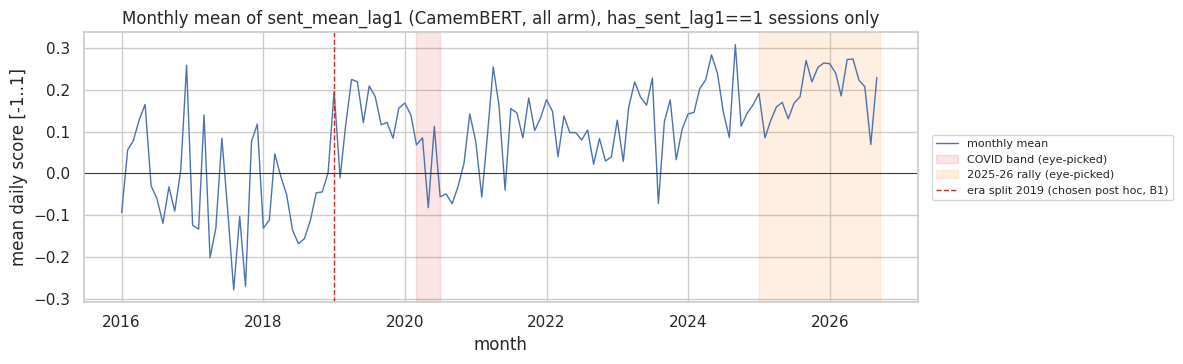

Yearly mean of sent_mean_lag1 on has_sent_lag1==1 sessions (composition drift in §4 and the B1 era confound this):
           mean  size
session              
2016     0.0251   250
2017    -0.0785   250
2018    -0.0758   249
2019     0.1461   249
2020     0.0399   256
2021     0.1054   248
2022     0.0868   257
2023     0.1199   251
2024     0.1823   248
2025     0.1868   245
2026     0.2182   173


In [21]:
s = df[df.has_sent_lag1 == 1].set_index("session")
mon = s.sent_mean_lag1.resample("MS").agg(["mean", "size"])
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(mon.index, mon["mean"], lw=1, label="monthly mean")
ax.axhline(0, color="k", lw=0.6)
shade(ax, df.session.max())
ax.axvline(pd.Timestamp(f"{ERA_CUT}-01-01"), color="tab:red", ls="--", lw=1, label="era split 2019 (chosen post hoc, B1)")
ax.set(title="Monthly mean of sent_mean_lag1 (CamemBERT, all arm), has_sent_lag1==1 sessions only",
       ylabel="mean daily score [-1..1]", xlabel="month")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
save(fig, "s5_monthly_sent_mean")
print("Yearly mean of sent_mean_lag1 on has_sent_lag1==1 sessions (composition drift in §4 and the B1 era confound this):")
print(s.sent_mean_lag1.groupby(s.index.year).agg(["mean", "size"]).to_string())

CamemBERT vs TF-IDF daily mean, pooled, n = 2676: Pearson +0.381, Spearman +0.369 (pooled across eras; see per era)
Means: CamemBERT +0.083, TF-IDF +0.142 (different instruments; not pooled)
                n  pearson  spearman
2016-18  749.0000   0.2128    0.2017
2019+   1927.0000   0.5392    0.5038
Per year: see the B1 table (camembert_tfidf_spearman).


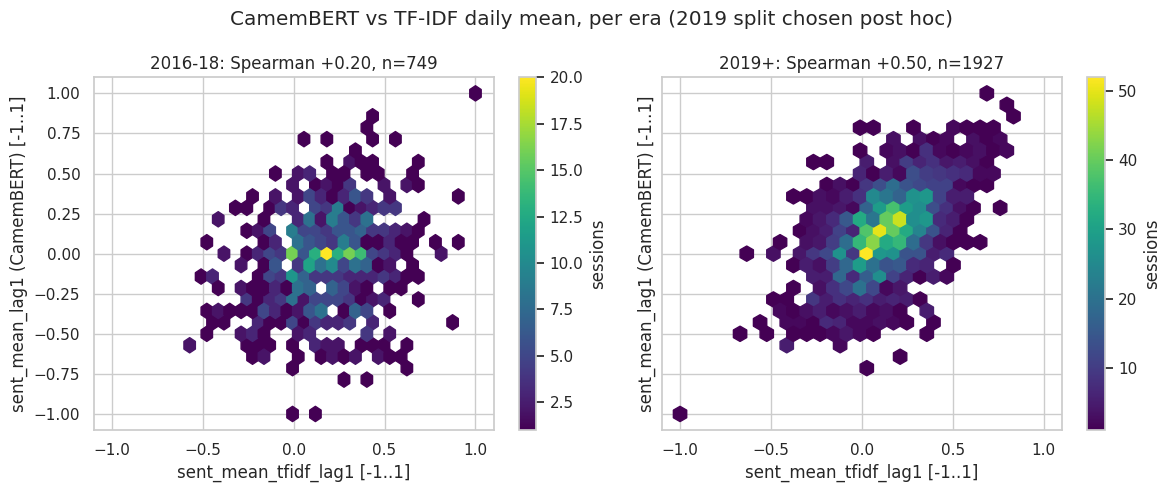

In [22]:
pear = both.sent_mean_lag1.corr(both.sent_mean_tfidf_lag1)
spear = both.sent_mean_lag1.corr(both.sent_mean_tfidf_lag1, method="spearman")
print(f"CamemBERT vs TF-IDF daily mean, pooled, n = {len(both)}: Pearson {pear:+.3f}, Spearman {spear:+.3f} (pooled across eras; see per era)")
print(f"Means: CamemBERT {both.sent_mean_lag1.mean():+.3f}, TF-IDF {both.sent_mean_tfidf_lag1.mean():+.3f} (different instruments; not pooled)")
era_tf = both.groupby(ERA[both.index]).apply(lambda g: pd.Series({"n": len(g),
    "pearson": g.sent_mean_lag1.corr(g.sent_mean_tfidf_lag1),
    "spearman": g.sent_mean_lag1.corr(g.sent_mean_tfidf_lag1, method="spearman")}), include_groups=False)
print(era_tf.to_string())
print("Per year: see the B1 table (camembert_tfidf_spearman).")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, e in zip(axes, ERAS):
    b = both[ERA[both.index] == e]
    hb = ax.hexbin(b.sent_mean_tfidf_lag1, b.sent_mean_lag1, gridsize=25, cmap="viridis", mincnt=1)
    fig.colorbar(hb, ax=ax, label="sessions")
    ax.set(title=f"{e}: Spearman {era_tf.loc[e, 'spearman']:+.2f}, n={int(era_tf.loc[e, 'n'])}",
           xlabel="sent_mean_tfidf_lag1 [-1..1]", ylabel="sent_mean_lag1 (CamemBERT) [-1..1]")
fig.suptitle("CamemBERT vs TF-IDF daily mean, per era (2019 split chosen post hoc)")
save(fig, "s5_camembert_vs_tfidf")

## §6 Lead-lag and contamination, per era (Q6, Q7)

**Question:** does each arm's `sent_mean_*_lag1` relate to `ret_next` (the prediction) differently from how it relates
to `ret_lag1` / `ret_lag0` (the echo of the session the headlines describe)?
**Pitfalls guarded:** columns are used **as-is**; no `.shift()` anywhere, no new lags. `sent_*_lag1[i]` pairs with
`ret_next[i]`; `ret_lag1[i]` is the session the headlines describe. Each arm uses its own `has_sent==1` rows, with n per
cell, and every table is shown per era (2016-18 / 2019+, boundary **chosen post hoc** after inspecting B1) as well as
pooled. On price reports the instrument is near-constant (-1) in 2016-18, with sign agreement with the described session
at chance level, and agrees with it 0.71-0.93 from 2019; the pooled numbers mix the two. B1 checks price-report headlines
only; the instrument itself is gradable only on the 150-row human evaluation split (PRD §3 "Instrumental", M2). The orthogonal arm uses the orphan `sent_resid_lag1` and is shown only as a row, not interpreted.
Correlations are descriptive; autocorrelated series inflate naive correlation standard errors, so the naive
±1.96/√n bands and Holm-adjusted naive p-values understate the true uncertainty.

In [23]:
prof_all = pd.concat({"pooled 2016-26": profile(), **{e: profile(ERA == e) for e in ERAS}}, names=["era"]).reset_index(level=0)
ok = prof_all.p_naive.notna()
prof_all.loc[ok, "p_holm"] = multipletests(prof_all.loc[ok, "p_naive"], method="holm")[1]
print(f"Holm across all {int(ok.sum())} Pearson cells (pooled + two eras x 4 arms x 5 targets). Naive SEs ignore autocorrelation.")
print("Era split chosen post hoc (B1). " + PL0_NOTE + " (rows 2016-18 / placebo below).")
for stat_ in ["pearson", "spearman", "n", "p_holm"]:
    print(f"\n{stat_}:")
    print(prof_all.pivot_table(index=["era", "arm"], columns="target", values=stat_, dropna=False)[TARGETS].to_string())
pv = prof_all[prof_all.era == "pooled 2016-26"].pivot(index="arm", columns="target", values="pearson")[TARGETS]
pv_era = {e: prof_all[prof_all.era == e].pivot(index="arm", columns="target", values="pearson")[TARGETS] for e in ERAS}

Holm across all 60 Pearson cells (pooled + two eras x 4 arms x 5 targets). Naive SEs ignore autocorrelation.
Era split chosen post hoc (B1). 2016-18 placebo input near-constant (347/353 = -1): its correlations are uninformative (rows 2016-18 / placebo below).

pearson:
target                            ret_lag3  ret_lag2  ret_lag1  ret_lag0  ret_next
era            arm                                                                
2016-18        all                 -0.0044   -0.0192   -0.0212   -0.0307   -0.0007
               ex_price            -0.0020   -0.0071   -0.0293   -0.0206    0.0026
               orthogonal_ORPHAN   -0.0046   -0.0186   -0.0143   -0.0280   -0.0009
               placebo             -0.0835   -0.0596    0.0000   -0.0625    0.0203
2019+          all                  0.0561    0.0795    0.1409    0.0852    0.0612
               ex_price             0.0367    0.0536    0.0656    0.0679    0.0544
               orthogonal_ORPHAN    0.0385    0.0554    0.0978    

Like-for-like: every arm restricted to the sessions where the placebo exists, per era (post hoc split; Pearson; n below):
2016-18 placebo input near-constant (347/353 = -1): its correlations are uninformative.
target                     ret_lag3  ret_lag2  ret_lag1  ret_lag0  ret_next
era     arm                                                                
2016-18 all                  0.0079    0.0087   -0.0121   -0.0444    0.0105
        ex_price             0.0098    0.0235   -0.0278   -0.0318    0.0059
        orthogonal_ORPHAN    0.0071    0.0062   -0.0063   -0.0418    0.0112
        placebo             -0.0835   -0.0596    0.0000   -0.0625    0.0203
2019+   all                  0.0852    0.1359    0.2151    0.0984    0.0346
        ex_price             0.0441    0.0789    0.0535    0.0589    0.0204
        orthogonal_ORPHAN    0.0771    0.1247    0.1870    0.0914    0.0287
        placebo              0.1420    0.1807    0.4913    0.1147    0.0404
target                     ret

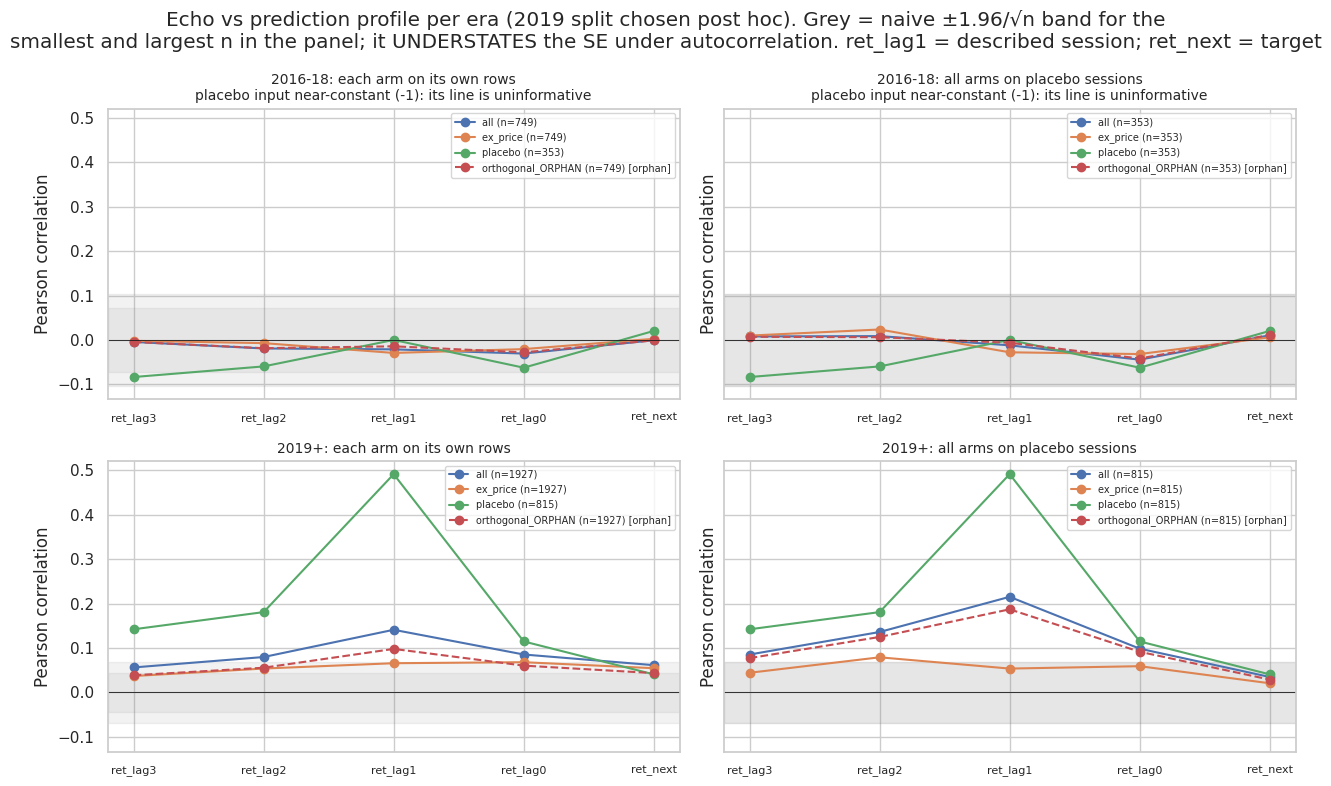


Difference of Pearson profiles, all minus ex_price (same sessions), per era = what price reports add to the all arm:
target                   ret_lag3  ret_lag2  ret_lag1  ret_lag0  ret_next
2016-18: all - ex_price   -0.0024   -0.0120    0.0081   -0.0100   -0.0032
2019+: all - ex_price      0.0193    0.0259    0.0753    0.0173    0.0069


In [24]:
placebo_days = df.has_sent_price_only_lag1 == 1
like = pd.concat({e: profile(placebo_days & (ERA == e)) for e in ERAS}, names=["era"]).reset_index(level=0)
print("Like-for-like: every arm restricted to the sessions where the placebo exists, per era (post hoc split; Pearson; n below):")
print(PL0_NOTE + ".")
print(like.pivot_table(index=["era", "arm"], columns="target", values="pearson")[TARGETS].to_string())
print(like.pivot_table(index=["era", "arm"], columns="target", values="n")[TARGETS].to_string())

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
for i, e in enumerate(ERAS):
    for j, (tab, label) in enumerate([(prof_all[prof_all.era == e], "each arm on its own rows"),
                                      (like[like.era == e], "all arms on placebo sessions")]):
        ax = axes[i, j]
        for arm in ARMS6:
            r = tab[tab.arm == arm].set_index("target").loc[TARGETS]
            ax.plot(TARGETS, r.pearson, marker="o", ls="--" if "ORPHAN" in arm else "-",
                    label=f"{arm} (n={int(r.n.iloc[0])})" + (" [orphan]" if "ORPHAN" in arm else ""))
        for n_ in sorted(tab.n.unique())[:1] + sorted(tab.n.unique())[-1:]:
            ax.axhspan(-1.96 / np.sqrt(n_), 1.96 / np.sqrt(n_), color="grey", alpha=0.1)
        ax.axhline(0, color="k", lw=0.6)
        ax.set_title(f"{e}: {label}" + ("\nplacebo input near-constant (-1): its line is uninformative" if e == "2016-18" else ""), fontsize=10)
        ax.set(ylabel="Pearson correlation")
        ax.tick_params(axis="x", labelsize=8)
        ax.legend(fontsize=7)
fig.suptitle("Echo vs prediction profile per era (2019 split chosen post hoc). Grey = naive ±1.96/√n band for the\n"
             "smallest and largest n in the panel; it UNDERSTATES the SE under autocorrelation. ret_lag1 = described session; ret_next = target")
save(fig, "s6_echo_profile")

diff = pd.DataFrame({f"{e}: all - ex_price": pv_era[e].loc["all"] - pv_era[e].loc["ex_price"] for e in ERAS}).T
print("\nDifference of Pearson profiles, all minus ex_price (same sessions), per era = what price reports add to the all arm:")
print(diff.to_string())

Per-year corr(sent_mean_*_lag1, ret_next), each arm on its own has_sent==1 rows (descriptive; band = naive 1.96/sqrt(n)):
 year      arm   n  pearson                          note   band
 2016      all 250  -0.0505                               0.1240
 2017      all 250   0.1151                               0.1240
 2018      all 249  -0.0278                               0.1242
 2019      all 249  -0.0144                               0.1242
 2020      all 256   0.0928                               0.1225
 2021      all 248   0.0905                               0.1245
 2022      all 257  -0.0344                               0.1223
 2023      all 251   0.0012                               0.1237
 2024      all 248   0.1018                               0.1245
 2025      all 245   0.0203                               0.1252
 2026      all 172   0.0277                               0.1494
 2016 ex_price 250  -0.0590                               0.1240
 2017 ex_price 250   0.1238      

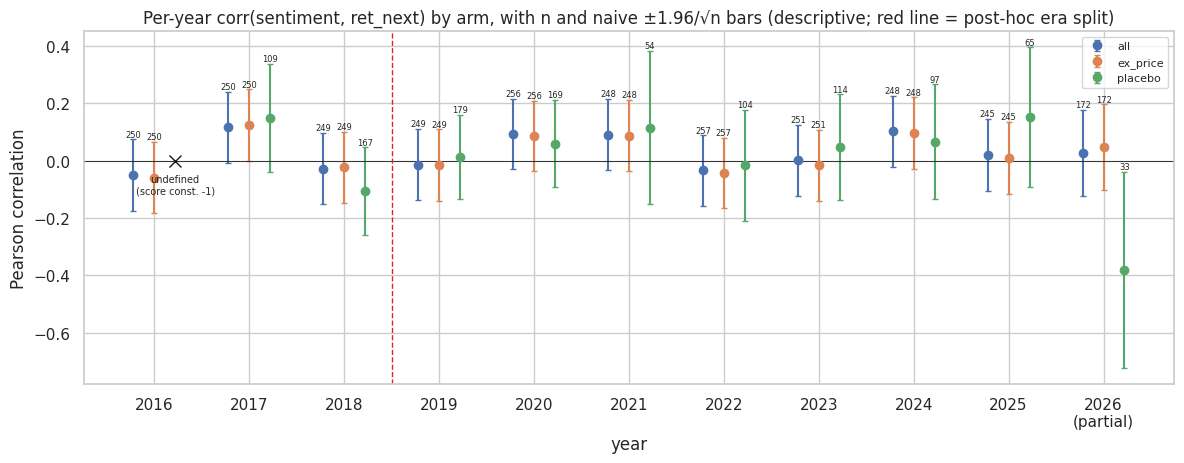

In [25]:
rows = []
for arm, (sc, flag) in ARMS.items():
    sub = df[(df[flag] == 1)].dropna(subset=["ret_next"])
    for y, gy in sub.groupby(sub.session.dt.year):
        constant = gy[sc].nunique() < 2
        rows.append(dict(year=y, arm=arm, n=len(gy), pearson=np.nan if constant else gy[sc].corr(gy.ret_next),
                         note="undefined (score constant -1)" if constant else ""))
py = pd.DataFrame(rows)
py["band"] = 1.96 / np.sqrt(py.n)
print("Per-year corr(sent_mean_*_lag1, ret_next), each arm on its own has_sent==1 rows (descriptive; band = naive 1.96/sqrt(n)):")
print(py.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4.8))
for k, arm in enumerate(ARMS):
    r = py[py.arm == arm]
    xpos = r.year + (k - 1) * 0.22
    ax.errorbar(xpos, r.pearson, yerr=r.band, fmt="o", capsize=2, label=arm)
    for x_, (_, rr) in zip(xpos, r.iterrows()):
        if rr.note:
            ax.plot(x_, 0, "x", color="k", ms=8)
            ax.annotate("undefined\n(score const. -1)", (x_, 0), textcoords="offset points", xytext=(0, -24), ha="center", fontsize=7)
        else:
            ax.annotate(f"{rr.n}", (x_, rr.pearson + rr.band), textcoords="offset points", xytext=(0, 2), ha="center", fontsize=6)
ax.axhline(0, color="k", lw=0.6)
ax.axvline(ERA_CUT - 0.5, color="tab:red", ls="--", lw=1)
ax.set_xticks(sorted(py.year.unique()))
ax.set_xticklabels([f"{y}" + ("\n(partial)" if y == 2026 else "") for y in sorted(py.year.unique())])
ax.set(title="Per-year corr(sentiment, ret_next) by arm, with n and naive ±1.96/√n bars (descriptive; red line = post-hoc era split)",
       xlabel="year", ylabel="Pearson correlation")
ax.legend(fontsize=8)
save(fig, "s6_per_year_corr")

**Note on the alignment fingerprint.** §1 asserts the spec's figure (+0.227 with `ret_lag1`, +0.038 with `ret_lag0`),
computed on the full frame **including** the 0-filled sessions. On the placebo's own sessions the pooled echo is a
mixture of two eras (B1). In 2016-18 the placebo input is near-constant (347 of 353 values are -1), so its correlations
there are **uninformative**, not a measured zero echo. In 2019+ the placebo peaks at `ret_lag1` and is small at
`ret_lag0`, which is what a correctly aligned `_lag1` feature looks like. The per-era numbers are the ones to quote
(era boundary chosen post hoc in B1; quote with that label).

## §7 Macro controls (Q9)

**Question:** how complete are the macro series, and how do their returns co-move with Tunindex?
**Pitfalls guarded:** a return on a forward-filled session should be 0, so every correlation drops `*_is_ffill == 1`
rows. This holds for stoxx50 and eur_tnd but **not for brent**, whose return was forward-filled with the level (table
below). `macro_controls.json`'s `session_coverage: 1.0` is post-fill and is not quoted as coverage. EuroStoxx closes
after BVMT, so the same-session correlation is ambiguous in direction; it is shown, not interpreted. The controls were
tested and rejected upstream (PRD §5); this section only describes.

Forward-fill coverage. Expected: a filled session has *_ret == 0. stoxx50 and eur_tnd match that;
brent does NOT: on filled sessions brent_ret repeats the previous session's return (the return itself was forward-filled).
 series  ffilled_sessions  share  longest_ffill_run  ret_nonzero_on_ffill  nonzero_ret_repeating_previous_on_ffill
  brent                80 0.0252                  3                    76                                       74
stoxx50               106 0.0333                  4                     0                                        0
eur_tnd                17 0.0053                  2                     0                                        0
Last row of the frame: 2026-09-16 | brent_is_ffill = 1


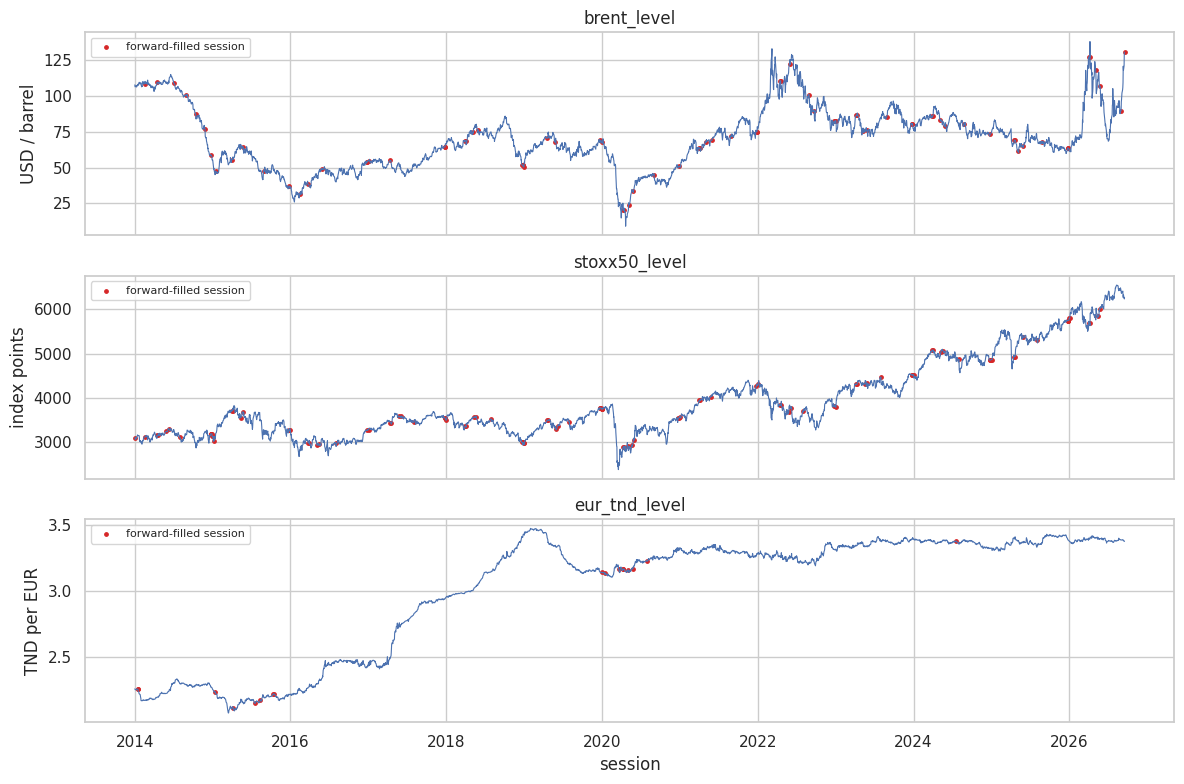

In [26]:
MAC = ["brent", "stoxx50", "eur_tnd"]
rows = []
for mname in MAC:
    f = df[f"{mname}_is_ffill"]
    runs = f.groupby((f != f.shift()).cumsum()).agg(["first", "size"])   # run-lengths of the 0/1 fill flag (flag column, not a feature)
    rv = df[f"{mname}_ret"].values
    rows.append(dict(series=mname, ffilled_sessions=int(f.sum()), share=f.mean(),
                     longest_ffill_run=int(runs.loc[runs["first"] == 1, "size"].max()),
                     ret_nonzero_on_ffill=int((df.loc[f == 1, f"{mname}_ret"] != 0).sum()),
                     nonzero_ret_repeating_previous_on_ffill=int(((rv[1:] == rv[:-1]) & (rv[1:] != 0))[f.values[1:] == 1].sum())))
macro_cov = pd.DataFrame(rows)
BRENT_CARRY = int(macro_cov.set_index("series").loc["brent", "nonzero_ret_repeating_previous_on_ffill"])
BRENT_NONZERO = int(macro_cov.set_index("series").loc["brent", "ret_nonzero_on_ffill"])
print("Forward-fill coverage. Expected: a filled session has *_ret == 0. stoxx50 and eur_tnd match that;")
print("brent does NOT: on filled sessions brent_ret repeats the previous session's return (the return itself was forward-filled).")
print(macro_cov.to_string(index=False))
print("Last row of the frame:", df.session.iloc[-1].date(), "| brent_is_ffill =", int(df.brent_is_ffill.iloc[-1]))

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
units = {"brent": "USD / barrel", "stoxx50": "index points", "eur_tnd": "TND per EUR"}
for ax, mname in zip(axes, MAC):
    ax.plot(df.session, df[f"{mname}_level"], lw=0.8)
    ff = df[df[f"{mname}_is_ffill"] == 1]
    ax.scatter(ff.session, ff[f"{mname}_level"], s=6, color="tab:red", label="forward-filled session")
    ax.set(title=f"{mname}_level", ylabel=units[mname])
    ax.legend(loc="upper left", fontsize=8)
axes[-1].set_xlabel("session")
save(fig, "s7_macro_levels")

In [27]:
rows = []
for mname in MAC:
    sub = df[df[f"{mname}_is_ffill"] == 0]
    for tcol in ["ret", "ret_next"]:
        p = sub[[f"{mname}_ret", tcol]].dropna()
        rows.append(dict(series=f"{mname}_ret", with_=tcol, n=len(p),
                         pearson=p.iloc[:, 0].corr(p.iloc[:, 1]), spearman=p.iloc[:, 0].corr(p.iloc[:, 1], method="spearman")))
print("Macro return correlations, forward-filled rows excluded (descriptive; stoxx50 same-session direction is ambiguous):")
print(pd.DataFrame(rows).rename(columns={"with_": "with"}).to_string(index=False))

Macro return correlations, forward-filled rows excluded (descriptive; stoxx50 same-session direction is ambiguous):
     series     with    n  pearson  spearman
  brent_ret      ret 3099   0.0021    0.0003
  brent_ret ret_next 3099   0.0203    0.0128
stoxx50_ret      ret 3073   0.0663    0.0227
stoxx50_ret ret_next 3072   0.0603    0.0048
eur_tnd_ret      ret 3162   0.0054    0.0287
eur_tnd_ret ret_next 3161   0.0071    0.0141


## §8 Volume (Q10)

**Question:** how often is volume missing, how often does the `vol_chg_lag0` clip bind, and does volume relate to news counts?
**Pitfalls guarded:** `volume == 0` is mostly **missing data coded 0**, not zero trading: two contiguous blocks
(September 2021 and April-May 2026) have normal non-zero returns and ranges. The 55 rows are split into holiday
phantoms (B2), contiguous missing blocks and isolated rows. `log_volume` encodes them as 0.0 (checked); they are set to
NaN for plotting so the gaps show, and `log(0)` is never taken. `vol_chg_lag0` is 0.0 on these rows **and on the row
after each** (by construction in `build_timeseries.py`), so a baseline feature holds a fill value there. The volume
unit is unverified, so the axis says "units per source". Volume is out of scope for H1 beyond `vol_chg_lag0` (PRD §4).

log_volume on volume==0 rows: [0.] | any log_volume == 0 with volume > 0: False

'volume missing (coded 0)' sessions by group and year:
col_0    contiguous block  holiday/phantom  isolated
session                                             
2015                    0                4         1
2017                    0                0         1
2020                    0                8         1
2021                   22                0         0
2022                    0                0         1
2023                    0                0         1
2025                    0                0         1
2026                   15                0         0

Contiguous missing-volume runs of >= 3 sessions (returns and ranges are normal, so trading happened).
The 2026 gap is 15 sessions 2026-04-14..05-06 broken by ONE row with volume (2026-04-30), so it shows as two runs:
     start        end  sessions  mean_abs_ret  mean_range_pct
2021-09-01 2021-09-30        22        0.0024         

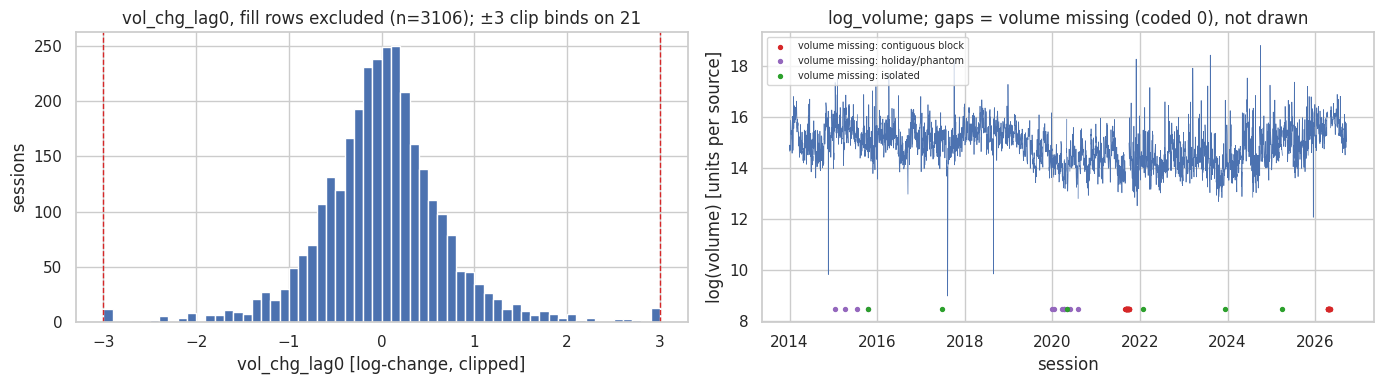

corr(log_headlines, log_volume), volume>0 rows, n=3124: Pearson +0.028, Spearman +0.015
(both series trend over 2014-2026, so a levels correlation partly reflects shared trend; descriptive only)


In [28]:
z = (df.volume == 0)
print("log_volume on volume==0 rows:", df.loc[z, "log_volume"].unique(), "| any log_volume == 0 with volume > 0:", bool(((df.log_volume == 0) & ~z).any()))
run_id = (z != z.shift()).cumsum()            # run-lengths of the 0/1 missing flag (not a feature column)
run_len = z.groupby(run_id).transform("size")
VOL_GROUP = pd.Series(np.select([z & PHANTOM, z & (run_len >= 3), z], ["holiday/phantom", "contiguous block", "isolated"], ""), index=df.index)
print("\n'volume missing (coded 0)' sessions by group and year:")
print(pd.crosstab(YEAR[z], VOL_GROUP[z]).to_string())
blocks = df[VOL_GROUP == "contiguous block"].groupby(run_id[VOL_GROUP == "contiguous block"]).agg(
    start=("session", "min"), end=("session", "max"), sessions=("session", "size"),
    mean_abs_ret=("abs_ret", "mean"), mean_range_pct=("range_pct", "mean"))
print("\nContiguous missing-volume runs of >= 3 sessions (returns and ranges are normal, so trading happened).")
print("The 2026 gap is 15 sessions 2026-04-14..05-06 broken by ONE row with volume (2026-04-30), so it shows as two runs:")
print(blocks.to_string(index=False))
print(f"(whole-frame mean abs_ret {df.abs_ret.mean():.4f}, mean range_pct {df.range_pct.mean():.4f})")

zv = z.values
after = np.r_[False, zv[:-1]]                 # row after a missing-volume row (array slicing)
fill_rows = zv | after
VOL_FILL = pd.Series(fill_rows, index=df.index)
print(f"\nvol_chg_lag0 == 0 on missing rows: {bool((df.vol_chg_lag0[zv] == 0).all())}; on the row after: {bool((df.vol_chg_lag0[after] == 0).all())}")
print(f"=> vol_chg_lag0 is a fill value on {int(fill_rows.sum())} sessions; total vol_chg_lag0 == 0 rows: {int((df.vol_chg_lag0 == 0).sum())}")

clip_hi, clip_lo = int((df.vol_chg_lag0 == 3).sum()), int((df.vol_chg_lag0 == -3).sum())
print(f"\nvol_chg_lag0 clip binding: +3 on {clip_hi} sessions, -3 on {clip_lo} sessions, total {clip_hi + clip_lo}")
print(df.vol_chg_lag0.describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df.vol_chg_lag0[~VOL_FILL], bins=60)
for v in (-3, 3):
    axes[0].axvline(v, color="tab:red", ls="--", lw=1)
axes[0].set(title=f"vol_chg_lag0, fill rows excluded (n={int((~VOL_FILL).sum())}); ±3 clip binds on {clip_hi + clip_lo}",
            xlabel="vol_chg_lag0 [log-change, clipped]", ylabel="sessions")
axes[1].plot(df.session, df.log_volume.where(~z), lw=0.5)
for grp, colr in [("contiguous block", "tab:red"), ("holiday/phantom", "tab:purple"), ("isolated", "tab:green")]:
    d = df[VOL_GROUP == grp]
    axes[1].scatter(d.session, np.full(len(d), df.log_volume[~z].min() - 0.5), s=8, color=colr, label=f"volume missing: {grp}")
axes[1].set(title="log_volume; gaps = volume missing (coded 0), not drawn", xlabel="session", ylabel="log(volume) [units per source]")
axes[1].legend(fontsize=7, loc="upper left")
save(fig, "s8_volume")

nz = df[~z]
print(f"corr(log_headlines, log_volume), volume>0 rows, n={len(nz)}: "
      f"Pearson {nz.log_headlines.corr(nz.log_volume):+.3f}, Spearman {nz.log_headlines.corr(nz.log_volume, method='spearman'):+.3f}")
print("(both series trend over 2014-2026, so a levels correlation partly reflects shared trend; descriptive only)")

## B2 Phantom sessions and data gaps in the price series

**Question:** which rows are not real trading sessions, or have missing fields?
**Pitfalls guarded:** rows are **described, not dropped or patched**. A phantom row copies the previous row's close,
high and low (compared by array slicing). It has two knock-on effects: `ret_next == 0` on the row before it is a fake
target, and the `ret` on the row after it is really a two-session return. Holiday tags use a hard-coded list of
Tunisian public holidays (fixed-date civil holidays, plus the Islamic holidays that fall on these dates, from
timeanddate.com "Holidays in Tunisia" for 2015 and 2020; lunar dates can differ by a day locally). An untagged row
means no known holiday, not "not a holiday".

In [29]:
FIXED = {(1, 1): "New Year", (1, 14): "Revolution Day", (3, 20): "Independence Day", (4, 9): "Martyrs' Day",
         (5, 1): "Labour Day", (7, 25): "Republic Day", (8, 13): "Women's Day", (10, 15): "Evacuation Day"}
LUNAR = {"2015-07-17": "Eid al-Fitr", "2015-10-14": "Islamic New Year", "2020-05-25": "Eid al-Fitr (day 2)",
         "2020-07-31": "Eid al-Adha"}
def holiday(d):
    return FIXED.get((d.month, d.day)) or LUNAR.get(str(d.date()), "")

ph = df[PHANTOM].copy()
ph_idx = ph.index.values
ph["weekday"] = ph.session.dt.day_name()
ph["holiday"] = ph.session.map(holiday)
ph["prev_session"] = df.session.values[ph_idx - 1]
ph["ret_next_on_prev_row (fake target)"] = df.ret_next.values[ph_idx - 1]
ph["ret_on_next_row (two-session return)"] = [df.ret.values[i + 1] if i + 1 < len(df) else np.nan for i in ph_idx]
print("Phantom rows: close, high, low identical to the previous row")
print(ph[["session", "weekday", "holiday", "volume", "close", "ret", "prev_session",
          "ret_next_on_prev_row (fake target)", "ret_on_next_row (two-session return)"]].to_string(index=False))
print(f"\n{int((ph.volume == 0).sum())} phantom rows with volume 0 (all holiday-tagged except "
      f"{ph.loc[(ph.volume == 0) & (ph.holiday == ''), 'session'].dt.date.tolist()}); "
      f"{int((ph.volume > 0).sum())} carry a volume while duplicating OHLC (scrape defect candidates).")
print("Zero-volume rows that are NOT phantom but fall on a tagged holiday:",
      df.loc[z & ~PHANTOM & (df.session.map(holiday) != ""), "session"].dt.date.tolist())

Phantom rows: close, high, low identical to the previous row
   session   weekday             holiday   volume      close    ret prev_session  ret_next_on_prev_row (fake target)  ret_on_next_row (two-session return)
2015-01-14 Wednesday      Revolution Day        0  5119.9800 0.0000   2015-01-13                              0.0000                               -0.0038
2015-04-09  Thursday        Martyrs' Day        0  5364.2700 0.0000   2015-04-08                              0.0000                                0.0028
2015-07-17    Friday         Eid al-Fitr        0  5660.6800 0.0000   2015-07-16                              0.0000                                0.0030
2015-08-13  Thursday         Women's Day  1759124  5591.5500 0.0000   2015-08-12                              0.0000                               -0.0037
2015-10-15  Thursday      Evacuation Day        0  5205.6400 0.0000   2015-10-14                              0.0000                                0.0014
2016-09-0

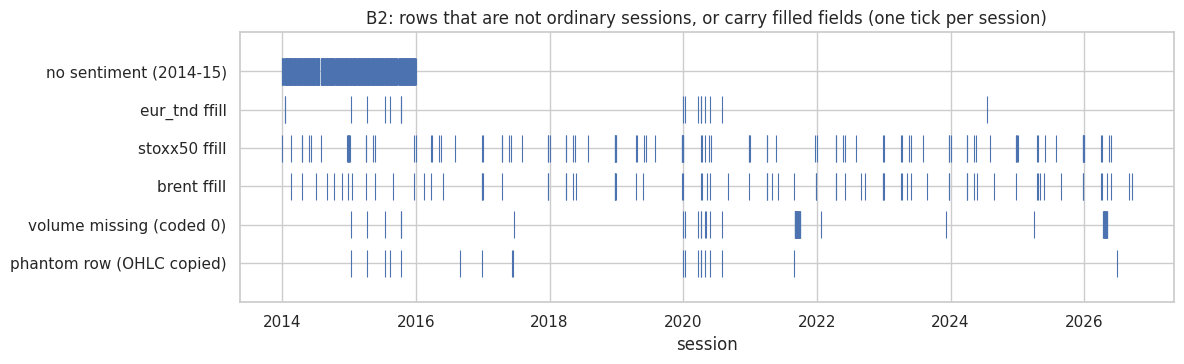

                           sessions
phantom row (OHLC copied)        19
volume missing (coded 0)         55
brent ffill                      80
stoxx50 ffill                   106
eur_tnd ffill                    17
no sentiment (2014-15)          503


In [30]:
strip = {"phantom row (OHLC copied)": PHANTOM,
         "volume missing (coded 0)": z,
         "brent ffill": df.brent_is_ffill == 1,
         "stoxx50 ffill": df.stoxx50_is_ffill == 1,
         "eur_tnd ffill": df.eur_tnd_is_ffill == 1,
         "no sentiment (2014-15)": df.has_sent_lag1 == 0}
fig, ax = plt.subplots(figsize=(12, 3.8))
for k, (lab, m_) in enumerate(strip.items()):
    ax.eventplot(df.session[m_].values.astype("datetime64[D]").astype(float), lineoffsets=k, linelengths=0.7, linewidths=0.8)
ax.set_yticks(range(len(strip)), list(strip))
ticks = pd.date_range("2014-01-01", "2027-01-01", freq="2YS")
ax.set_xticks(ticks.values.astype("datetime64[D]").astype(float), [t.year for t in ticks])
ax.set(title="B2: rows that are not ordinary sessions, or carry filled fields (one tick per session)", xlabel="session")
save(fig, "b2_gap_timeline")
print(pd.DataFrame({k: [int(v.sum())] for k, v in strip.items()}, index=["sessions"]).T.to_string())

## B3 Tail and leverage

**Question:** which days drive the dependence statistics, and how much do the headline numbers move without them?
**Pitfalls guarded:** this is a robustness **description**, not outlier removal. Every other cell keeps all rows.
Winsorising at the 1st/99th percentile and excluding the COVID band (eye-picked) are views, not corrections.
The per-era rows use the 2016-18 / 2019+ split **chosen post hoc** in B1.

In [31]:
top = df.assign(abs_r=df.ret.abs()).nlargest(20, "abs_r")[["session", "ret", "abs_r", "n_headlines", "has_sent_lag1"]]
print("Top 20 |ret| sessions:")
print(top.to_string(index=False))

in_covid = (df.session >= COVID[0]) & (df.session <= COVID[1])
lo_q, hi_q = df.ret.quantile([0.01, 0.99])
w_ret = df.ret.clip(lo_q, hi_q)
acf_views = pd.Series({
    "full sample (Pearson)": ACF1_RET,
    "excluding COVID band rows (Pearson, corr(ret, ret_lag1))": df.loc[~in_covid, "ret"].corr(df.loc[~in_covid, "ret_lag1"]),
    "1%/99% winsorised ret (acf)": acf(w_ret, nlags=1)[1],
    "Spearman corr(ret, ret_lag1)": df.ret.corr(df.ret_lag1, method="spearman"),
})
print("\nACF(1) of ret under different views:")
print(acf_views.to_string())

rows = []
for arm, (sc, flag) in ARMS.items():
    for e in ["pooled"] + ERAS:
        sub = df[(df[flag] == 1) & df.ret_next.notna() & ((ERA == e) if e != "pooled" else True)]
        cut = sub.ret_next.abs().quantile(0.99)
        trimmed = sub[sub.ret_next.abs() <= cut]
        rows.append(dict(arm=arm, era=e, n_full=len(sub), corr_full=sub[sc].corr(sub.ret_next),
                         n_trim=len(trimmed), corr_drop_top1pct_abs_ret_next=trimmed[sc].corr(trimmed.ret_next)))
print("\ncorr(sentiment, ret_next): full vs dropping the top 1% |ret_next| (descriptive; era split chosen post hoc, B1):")
print(pd.DataFrame(rows).to_string(index=False))

Top 20 |ret| sessions:
   session     ret  abs_r  n_headlines  has_sent_lag1
2020-03-16 -0.0398 0.0398           18              1
2020-03-17 -0.0383 0.0383           14              1
2026-07-28 -0.0347 0.0347           15              1
2018-09-06 -0.0296 0.0296           17              1
2020-03-13 -0.0277 0.0277           17              1
2018-12-10 -0.0273 0.0273           19              1
2018-09-07  0.0271 0.0271            9              1
2020-10-01 -0.0251 0.0251           15              1
2015-03-18 -0.0247 0.0247           11              0
2020-04-02 -0.0233 0.0233           17              1
2026-07-16  0.0230 0.0230           16              1
2026-01-27  0.0226 0.0226           13              1
2016-03-02  0.0214 0.0214           11              1
2026-06-25  0.0209 0.0209           23              1
2026-07-15  0.0209 0.0209           26              1
2026-08-19  0.0201 0.0201           17              1
2026-01-15  0.0194 0.0194           16              1
2020-

## B4 Calendar effects: next-session weekday and Ramadan

**Question:** does the next-session direction or the news flow vary by weekday or during Ramadan?
**Pitfalls guarded:** the next-session weekday comes from the `dow_next_*` columns (Friday is the omitted category).
Weekday effects are confounded with the 2025 drift, so every table is split pre-2025 / 2025+ (the 2025 cut was
**picked by eye** from the price chart, §2). Monday rows aggregate
about three days of news, so their `sent_mean` averages more headlines and has a smaller sd by construction. χ² p-values
are naive (independence assumed). Ramadan is flagged on the **target** session using hard-coded 1 Ramadan and Eid
al-Fitr dates (Umm al-Qura calendar via timeanddate.com; the Tunisian dates can differ by one day). Descriptive only.

ret_next by NEXT-session weekday, per period:
 period next_weekday   n  up_share  up_lo  up_hi  mean_ret_next  sd_ret_next
2014-24          Mon 549    0.5337 0.4919 0.5750         0.0004       0.0044
2014-24          Tue 550    0.4891 0.4475 0.5308         0.0000       0.0043
2014-24          Wed 554    0.4838 0.4424 0.5253        -0.0000       0.0042
2014-24          Thu 554    0.5307 0.4891 0.5719         0.0004       0.0043
2014-24          Fri 554    0.5993 0.5579 0.6393         0.0007       0.0040
  2025+          Mon  86    0.6047 0.4990 0.7014         0.0002       0.0050
  2025+          Tue  85    0.5647 0.4588 0.6650         0.0012       0.0067
  2025+          Wed  83    0.6988 0.5931 0.7869         0.0033       0.0061
  2025+          Thu  78    0.6667 0.5564 0.7613         0.0021       0.0060
  2025+          Fri  85    0.6706 0.5652 0.7612         0.0013       0.0054
2014-24: naive chi2 (weekday x up) = 19.1, dof 4, p = 0.0008  (2025 cut picked by eye)
2025+: naive chi2 (w

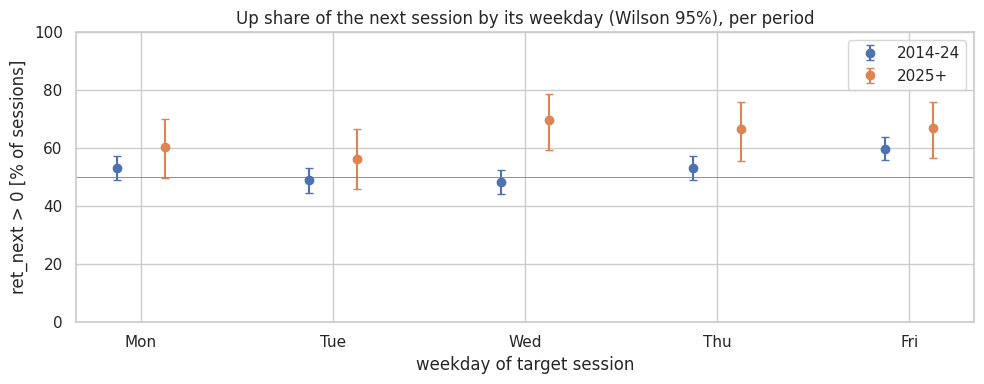


By the ROW's weekday (Monday rows aggregate the weekend's news):
               n  mean_n_headlines  sd_sent_mean_lag1 (has_sent==1)
row_weekday                                                        
Mon          635           20.8142                           0.2358
Tue          635           12.3087                           0.2804
Wed          637           12.7425                           0.2918
Thu          633           12.7820                           0.2842
Fri          639           13.2473                           0.2610


In [32]:
t = df.dropna(subset=["ret_next"]).copy()
t["next_weekday"] = np.select([t[c] == 1 for c in DOW], ["Mon", "Tue", "Wed", "Thu"], "Fri")
t["period"] = np.where(t.session.dt.year < 2025, "2014-24", "2025+")
rows = []
for (per, wd), g in t.groupby(["period", "next_weekday"]):
    k, n = int((g.ret_next > 0).sum()), len(g)
    lo, hi = wilson(k, n)
    rows.append(dict(period=per, next_weekday=wd, n=n, up_share=k / n, up_lo=lo, up_hi=hi,
                     mean_ret_next=g.ret_next.mean(), sd_ret_next=g.ret_next.std()))
wk = pd.DataFrame(rows)
wk["next_weekday"] = pd.Categorical(wk.next_weekday, ["Mon", "Tue", "Wed", "Thu", "Fri"])
wk = wk.sort_values(["period", "next_weekday"])
print("ret_next by NEXT-session weekday, per period:")
print(wk.to_string(index=False))
for per, g in t.groupby("period"):
    chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab(g.next_weekday, g.ret_next > 0))
    print(f"{per}: naive chi2 (weekday x up) = {chi2:.1f}, dof {dof}, p = {p:.4f}  (2025 cut picked by eye)")

fig, ax = plt.subplots(figsize=(10, 4))
for k, (per, g) in enumerate(wk.groupby("period", observed=True)):
    xs = np.arange(5) + (k - 0.5) * 0.25
    ax.errorbar(xs, g.up_share * 100, yerr=[(g.up_share - g.up_lo) * 100, (g.up_hi - g.up_share) * 100], fmt="o", capsize=3,
                label=f"{per}")
ax.set_xticks(range(5), ["Mon", "Tue", "Wed", "Thu", "Fri"])
ax.axhline(50, color="grey", lw=0.6)
ax.set(title="Up share of the next session by its weekday (Wilson 95%), per period", xlabel="weekday of target session",
       ylabel="ret_next > 0 [% of sessions]", ylim=(0, 100))
ax.legend()
save(fig, "b4_weekday")

rw = df.assign(row_weekday=df.session.dt.day_name().str[:3])
news = rw.groupby("row_weekday").agg(n=("n_headlines", "size"), mean_n_headlines=("n_headlines", "mean"))
news["sd_sent_mean_lag1 (has_sent==1)"] = rw[rw.has_sent_lag1 == 1].groupby("row_weekday").sent_mean_lag1.std()
print("\nBy the ROW's weekday (Monday rows aggregate the weekend's news):")
print(news.reindex(["Mon", "Tue", "Wed", "Thu", "Fri"]).to_string())

In [33]:
RAMADAN = {  # year: (1 Ramadan, Eid al-Fitr) -- Umm al-Qura via timeanddate.com; Tunisia may differ by a day
    2014: ("2014-06-28", "2014-07-28"), 2015: ("2015-06-18", "2015-07-17"), 2016: ("2016-06-06", "2016-07-06"),
    2017: ("2017-05-27", "2017-06-25"), 2018: ("2018-05-16", "2018-06-15"), 2019: ("2019-05-06", "2019-06-04"),
    2020: ("2020-04-24", "2020-05-24"), 2021: ("2021-04-13", "2021-05-13"), 2022: ("2022-04-02", "2022-05-02"),
    2023: ("2023-03-23", "2023-04-21"), 2024: ("2024-03-11", "2024-04-10"), 2025: ("2025-03-01", "2025-03-30"),
    2026: ("2026-02-18", "2026-03-20")}
target_session = pd.Series(np.r_[df.session.values[1:], np.datetime64("NaT")], index=df.index)   # session i+1, array slicing
is_ram = pd.Series(False, index=df.index)
for a, b in RAMADAN.values():
    is_ram |= (target_session >= a) & (target_session < b)
t["ramadan_target"] = is_ram[t.index]
rows = []
for (per, ram), g in t.groupby(["period", "ramadan_target"]):
    k, n = int((g.ret_next > 0).sum()), len(g)
    lo, hi = wilson(k, n)
    rows.append(dict(period=per, ramadan_target=ram, n=n, up_share=k / n, up_lo=lo, up_hi=hi, mean_ret_next=g.ret_next.mean()))
k, n = int((t[t.ramadan_target].ret_next > 0).sum()), int(t.ramadan_target.sum())
print(f"Ramadan target sessions, all years: n={n}, up share {k / n:.3f}; non-Ramadan up share {(t[~t.ramadan_target].ret_next > 0).mean():.3f}")
print(pd.DataFrame(rows).to_string(index=False))

Ramadan target sessions, all years: n=265, up share 0.623; non-Ramadan up share 0.535
 period  ramadan_target    n  up_share  up_lo  up_hi  mean_ret_next
2014-24           False 2536    0.5197 0.5003 0.5391         0.0002
2014-24            True  225    0.6133 0.5483 0.6746         0.0010
  2025+           False  377    0.6366 0.5869 0.6836         0.0015
  2025+            True   40    0.6750 0.5202 0.7992         0.0024


## B5 Sentiment vs `ret_next` by volatility regime

**Question:** does the (descriptive) sentiment-to-`ret_next` correlation differ between calm and volatile periods?
**Pitfalls guarded:** the regime proxy is the row mean of the existing `abs_ret_lag0..3` columns (no rolling, no shift).
Tercile cut-offs are full-sample, so this is a description, not a tradeable rule; there is no regression and no H1
re-test. No p-values are shown; bars are naive ±1.96/√n and understate the SE under autocorrelation.

Full-sample tercile cut-offs of mean(abs_ret_lag0..3): [0.00194867 0.00323352]
     arm     era tercile   n  pearson  spearman
     all 2016-18     low 204   0.0579    0.0564
     all 2016-18     mid 271   0.0207   -0.0092
     all 2016-18    high 274  -0.0453   -0.0712
     all   2019+     low 703  -0.0403   -0.0323
     all   2019+     mid 591   0.0706    0.0517
     all   2019+    high 632   0.1140    0.1083
ex_price 2016-18     low 204   0.0400    0.0395
ex_price 2016-18     mid 271   0.0249   -0.0073
ex_price 2016-18    high 274  -0.0323   -0.0340
ex_price   2019+     low 703  -0.0431   -0.0357
ex_price   2019+     mid 591   0.0605    0.0390
ex_price   2019+    high 632   0.1074    0.1200
 placebo 2016-18     low 100   0.0140   -0.0126
 placebo 2016-18     mid 113   0.0675    0.0287
 placebo 2016-18    high 140  -0.0244   -0.0388
 placebo   2019+     low 284  -0.0247   -0.0157
 placebo   2019+     mid 257   0.1148    0.0979
 placebo   2019+    high 274   0.0339    0.0002


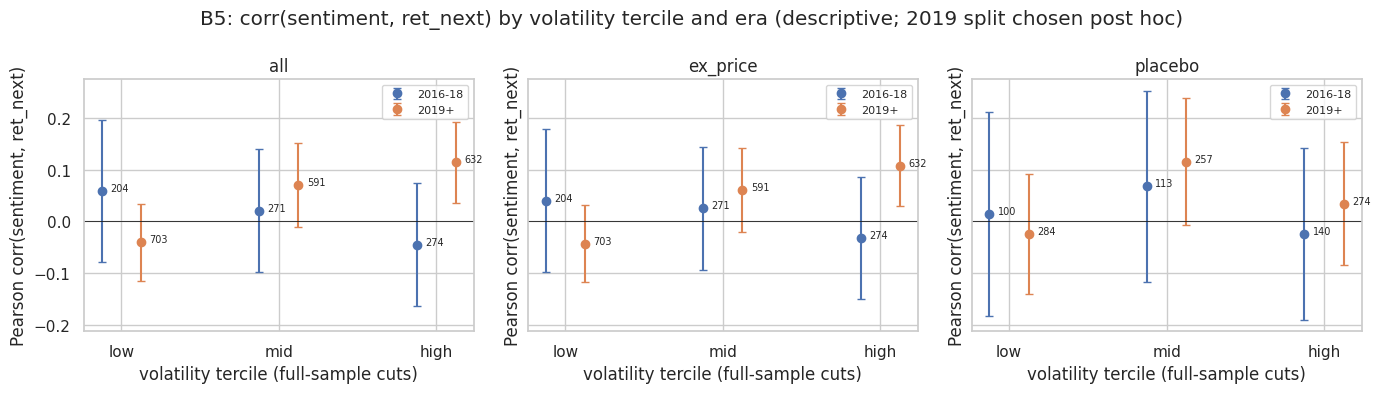

In [34]:
vol_proxy = df[["abs_ret_lag0", "abs_ret_lag1", "abs_ret_lag2", "abs_ret_lag3"]].mean(axis=1)
cuts = vol_proxy.quantile([1 / 3, 2 / 3]).values
TERC = pd.Series(pd.cut(vol_proxy, [-np.inf, *cuts, np.inf], labels=["low", "mid", "high"]), index=df.index)
print("Full-sample tercile cut-offs of mean(abs_ret_lag0..3):", cuts)
rows = []
for arm, (sc, flag) in ARMS.items():
    for e in ERAS:
        for tc in ["low", "mid", "high"]:
            sub = df[(df[flag] == 1) & (ERA == e) & (TERC == tc)].dropna(subset=["ret_next"])
            const = sub[sc].nunique() < 2
            rows.append(dict(arm=arm, era=e, tercile=tc, n=len(sub),
                             pearson=np.nan if const else sub[sc].corr(sub.ret_next),
                             spearman=np.nan if const else sub[sc].corr(sub.ret_next, method="spearman")))
b5 = pd.DataFrame(rows)
print(b5.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, arm in zip(axes, ARMS):
    for k, e in enumerate(ERAS):
        r = b5[(b5.arm == arm) & (b5.era == e)]
        xs = np.arange(3) + (k - 0.5) * 0.25
        ax.errorbar(xs, r.pearson, yerr=1.96 / np.sqrt(r.n), fmt="o", capsize=3, label=e)
        for x_, (_, rr) in zip(xs, r.iterrows()):
            ax.annotate(str(rr.n), (x_, rr.pearson), textcoords="offset points", xytext=(6, 0), fontsize=7)
    ax.axhline(0, color="k", lw=0.6)
    ax.set_xticks(range(3), ["low", "mid", "high"])
    ax.set(title=f"{arm}", xlabel="volatility tercile (full-sample cuts)", ylabel="Pearson corr(sentiment, ret_next)")
    ax.legend(fontsize=8)
fig.suptitle("B5: corr(sentiment, ret_next) by volatility tercile and era (descriptive; 2019 split chosen post hoc)")
save(fig, "b5_vol_regime")

## B6 News volume vs absolute returns, trend-controlled

**Question:** does the number of headlines co-move with the size of returns, beyond a shared trend?
**Pitfalls guarded:** both series trend upward in 2025-26, so the pooled correlation is partly shared trend. The
within-year version demeans each series inside its calendar year first. `|ret_next|` is the absolute value of the
existing target column (no shift). Descriptive only.

                              pair    n  spearman_pooled  spearman_within_year
log_headlines_lag0 vs abs_ret_lag1 3178           0.0757                0.0523
log_headlines_lag0 vs abs_ret_lag0 3178           0.0659                0.0356
log_headlines_lag0 vs abs_ret_next 3178           0.0662                0.0374
         mean_log_headlines  mean_abs_ret
session                                  
2014                 2.3130        0.0029
2015                 2.6240        0.0031
2016                 2.4553        0.0031
2017                 2.4286        0.0025
2018                 2.5431        0.0041
2019                 2.6246        0.0026
2020                 2.6182        0.0040
2021                 2.4504        0.0026
2022                 2.7086        0.0024
2023                 2.7239        0.0026
2024                 2.7269        0.0024
2025                 3.0133        0.0028
2026                 3.1221        0.0063


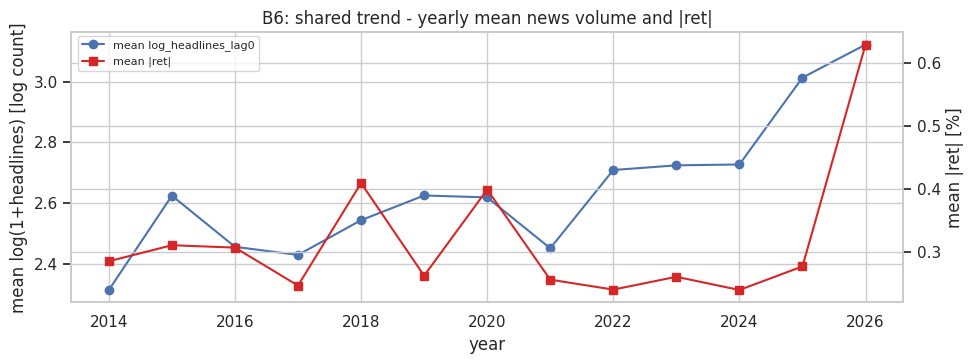

In [35]:
v = df.dropna(subset=["ret_next"]).assign(abs_ret_next=lambda d: d.ret_next.abs())
rows = []
for other in ["abs_ret_lag1", "abs_ret_lag0", "abs_ret_next"]:
    pooled = v.log_headlines_lag0.corr(v[other], method="spearman")
    dm = v[["log_headlines_lag0", other]] - v.groupby(v.session.dt.year)[["log_headlines_lag0", other]].transform("mean")
    rows.append(dict(pair=f"log_headlines_lag0 vs {other}", n=len(v), spearman_pooled=pooled,
                     spearman_within_year=dm.log_headlines_lag0.corr(dm[other], method="spearman")))
print(pd.DataFrame(rows).to_string(index=False))

yy = v.groupby(v.session.dt.year).agg(mean_log_headlines=("log_headlines_lag0", "mean"), mean_abs_ret=("abs_ret", "mean"))
print(yy.to_string())
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(yy.index, yy.mean_log_headlines, marker="o", label="mean log_headlines_lag0")
ax.set(xlabel="year", ylabel="mean log(1+headlines) [log count]", title="B6: shared trend - yearly mean news volume and |ret|")
ax2 = ax.twinx()
ax2.plot(yy.index, yy.mean_abs_ret * 100, marker="s", color="tab:red", label="mean |ret|")
ax2.set_ylabel("mean |ret| [%]")
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.9), fontsize=8)
save(fig, "b6_news_vs_absret")

## B7 Label mix and dispersion over time

**Question:** how does the positive / neutral / negative mix of daily CamemBERT labels, and the dispersion of the daily
mean, evolve?
**Pitfalls guarded:** neutral share = 1 - pos - neg. The sd of a daily mean shrinks roughly as 1/√n and headlines per
session nearly double in 2025-26, so the sd is shown next to mean `sent_n`; a lower sd is not "calmer news". The B1
era and §4 composition drift both confound this. `has_sent_lag1 == 1` rows only.

Per-year mean of the daily label shares (session-weighted) and dispersion:
           n    pos  neutral    neg  sd_sent_mean  mean_sent_n  sd_x_sqrt_mean_n (rough scale-adjusted)
session                                                                                                
2016     250 0.3228   0.3794 0.2978        0.2845      11.5640                                   0.9673
2017     250 0.2761   0.3693 0.3546        0.3057      11.1960                                   1.0228
2018     249 0.2584   0.4075 0.3341        0.2488      12.5944                                   0.8830
2019     249 0.3650   0.4162 0.2188        0.2331      13.5261                                   0.8572
2020     256 0.3418   0.3562 0.3019        0.2761      13.6797                                   1.0212
2021     248 0.3597   0.3859 0.2543        0.2854      11.5605                                   0.9705
2022     257 0.3522   0.3823 0.2655        0.2535      15.1440                               

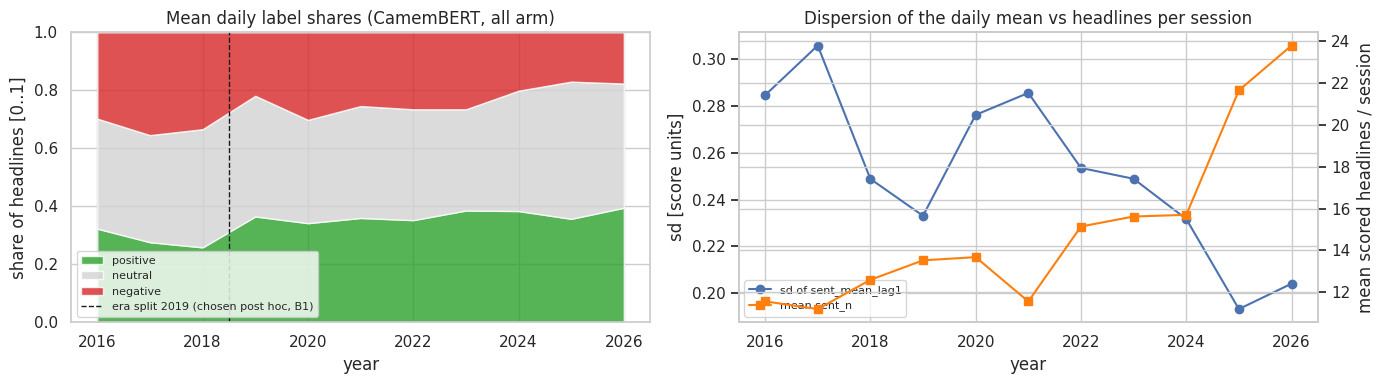

In [36]:
s7 = df[df.has_sent_lag1 == 1].assign(neu=lambda d: 1 - d.sent_pos_share_lag1 - d.sent_neg_share_lag1)
b7 = s7.groupby(s7.session.dt.year).agg(n=("sent_n", "size"), pos=("sent_pos_share_lag1", "mean"), neutral=("neu", "mean"),
                                        neg=("sent_neg_share_lag1", "mean"), sd_sent_mean=("sent_mean_lag1", "std"),
                                        mean_sent_n=("sent_n", "mean"))
b7["sd_x_sqrt_mean_n (rough scale-adjusted)"] = b7.sd_sent_mean * np.sqrt(b7.mean_sent_n)
print("Per-year mean of the daily label shares (session-weighted) and dispersion:")
print(b7.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].stackplot(b7.index, b7.pos, b7.neutral, b7.neg, labels=["positive", "neutral", "negative"],
                  colors=["tab:green", "lightgrey", "tab:red"], alpha=0.8)
axes[0].axvline(ERA_CUT - 0.5, color="k", ls="--", lw=1, label="era split 2019 (chosen post hoc, B1)")
axes[0].set(title="Mean daily label shares (CamemBERT, all arm)", xlabel="year", ylabel="share of headlines [0..1]", ylim=(0, 1))
axes[0].legend(fontsize=8, loc="lower left")
axes[1].plot(b7.index, b7.sd_sent_mean, marker="o", label="sd of sent_mean_lag1")
axes[1].set(title="Dispersion of the daily mean vs headlines per session", xlabel="year", ylabel="sd [score units]")
ax2 = axes[1].twinx()
ax2.plot(b7.index, b7.mean_sent_n, marker="s", color="tab:orange", label="mean sent_n")
ax2.set_ylabel("mean scored headlines / session")
h1_, l1_ = axes[1].get_legend_handles_labels()
h2_, l2_ = ax2.get_legend_handles_labels()
axes[1].legend(h1_ + h2_, l1_ + l2_, fontsize=8, loc="lower left")
save(fig, "b7_label_mix")

## B8 Missingness vs target

**Question:** are coverage gaps and fills random with respect to returns?
**Pitfalls guarded:** under the 0-fill convention `has_sent_price_only_lag1` is itself a feature, so any link between
that flag and |ret| is information carried by the indicator (a price report was written), not by sentiment. Its
comparison is restricted to 2016+ (`has_sent_lag1 == 1`) so the 2014-15 blackout does not enter. Descriptive; naive CIs.

In [37]:
flags8 = {"has_sent_price_only_lag1 (2016+)": (df.has_sent_price_only_lag1 == 1, df.has_sent_lag1 == 1),
          "brent_is_ffill": (df.brent_is_ffill == 1, None),
          "stoxx50_is_ffill": (df.stoxx50_is_ffill == 1, None),
          "eur_tnd_is_ffill": (df.eur_tnd_is_ffill == 1, None),
          "volume missing (coded 0)": (z, None),
          "phantom row": (PHANTOM, None)}
rows = []
for name, (flag, scope) in flags8.items():
    base_ = df.ret_next.notna() & (scope if scope is not None else True)
    for val in [True, False]:
        g = df[base_ & (flag == val)]
        k, n = int((g.ret_next > 0).sum()), len(g)
        lo, hi = wilson(k, n) if n else (np.nan, np.nan)
        rows.append(dict(flag=name, value=int(val), n=n, mean_abs_ret_lag1=g.abs_ret_lag1.mean(),
                         up_share_ret_next=k / n if n else np.nan, up_lo=lo, up_hi=hi))
print(pd.DataFrame(rows).to_string(index=False))
print("Phantom rows: ret_next on a phantom row is the return INTO the next real session, so their up share is not a gap effect.")

                            flag  value    n  mean_abs_ret_lag1  up_share_ret_next  up_lo  up_hi
has_sent_price_only_lag1 (2016+)      1 1168             0.0033             0.5437 0.5150 0.5720
has_sent_price_only_lag1 (2016+)      0 1507             0.0030             0.5534 0.5282 0.5783
                  brent_is_ffill      1   79             0.0031             0.6203 0.5100 0.7193
                  brent_is_ffill      0 3099             0.0031             0.5402 0.5226 0.5577
                stoxx50_is_ffill      1  106             0.0034             0.5283 0.4340 0.6207
                stoxx50_is_ffill      0 3072             0.0031             0.5426 0.5250 0.5602
                eur_tnd_is_ffill      1   17             0.0030             0.6471 0.4130 0.8269
                eur_tnd_is_ffill      0 3161             0.0031             0.5416 0.5242 0.5589
        volume missing (coded 0)      1   55             0.0024             0.6545 0.5225 0.7664
        volume missing (coded 

## §9 Summary

The findings table is generated from the values computed above (so it cannot drift from the notebook), followed by the
open issues routed to the statistician, auditor, instrument agent and reproducer (observations, not verdicts), and a
verbatim quote of the H1 numbers from `hypothesis_results.json`. **No new verdict is formed here.**

In [38]:
ur_ret = unit_root[unit_root.series == "ret"]
ur_lc = unit_root[unit_root.series == "log(close)"]
covid_sd = df[(df.session >= COVID[0]) & (df.session <= COVID[1])].ret.std()
y = per_year.sd
gl = cov.global_share_corpus
ps = cov.price_share_corpus
e0, e1 = ERAS
pe0, pe1 = pv_era[e0], pv_era[e1]
agree0 = b1.loc[2016:2018, "sign_agreement"]
agree1 = b1.loc[2019:, "sign_agreement"]
vg = VOL_GROUP[z].value_counts()
rows = [
 ("B1 (headline)", f"Placebo sign agreement with sign(ret_lag1): {agree0.min():.2f}-{agree0.max():.2f} in 2016-18 vs {agree1.min():.2f}-{agree1.max():.2f} in 2019+; share of placebo scores at -1: {b1.loc[2016:2018, 'share_m1'].min():.2f}-{b1.loc[2016:2018, 'share_m1'].max():.2f} vs {b1.loc[2019:, 'share_m1'].min():.2f}-{b1.loc[2019:, 'share_m1'].max():.2f}. CamemBERT-TF-IDF Spearman {era_tf.loc[e0, 'spearman']:+.2f} vs {era_tf.loc[e1, 'spearman']:+.2f}. Era split chosen post hoc."),
 ("Q1", f"ADF p on ret, per sub-sample: {', '.join(f'{v:.3g}' for v in ur_ret.adf_p)}; on log(close): {', '.join(f'{v:.3g}' for v in ur_lc.adf_p)} (order: {', '.join(ur_ret['sample'])}). Daily sd {y.loc[2021:2024].mean():.4f} (2021-24 mean of yearly sd) vs {y.loc[2026]:.4f} in 2026; COVID band sd {covid_sd:.4f}. Regime bands eye-picked; CUSUM p={p_cusum:.4f} reflects the drifting mean, descriptive."),
 ("Q2", f"ACF(1) ret {ACF1_RET:+.3f}, abs_ret {ACF1_ABS:+.3f}; Ljung-Box and ARCH-LM reject no-dependence. ACF(1) views (B3): excl. COVID {acf_views.iloc[1]:+.3f}, winsorised {acf_views.iloc[2]:+.3f}, Spearman {acf_views.iloc[3]:+.3f}. Level ACF is not directional predictability."),
 ("Q3", f"Up base rate {UP_RATE:.4f} overall, yearly range {base.up_share.min():.3f}..{base.up_share.max():.3f} (2025: {base.loc[2025, 'up_share']:.3f}, Wilson {base.loc[2025, 'up_lo']:.3f}-{base.loc[2025, 'up_hi']:.3f}). {N_ZERO_TARGET} targets are phantom rows, not flat markets."),
 ("Q4", f"has_sent_lag1 = 0 on exactly the 503 sessions 2014-01-02..2015-12-31 (unscored, not neutral); placebo covers {int(df.has_sent_price_only_lag1.sum())} sessions, {single:.0%} of them on one headline."),
 ("Q5", f"Composition drifts: global-linked share {gl.iloc[0]:.1%} (2014) -> {gl.loc[2025]:.1%} (2025); corpus-level price-report share {ps.iloc[0]:.1%} -> {ps.loc[2025]:.1%}; median headlines/session {cov.median_n_headlines.iloc[0]:.0f} -> {cov.median_n_headlines.loc[2025]:.0f}. Source mix not observable in this frame."),
 ("Q6/Q7", f"Era split chosen post hoc (B1). Placebo echo corr with ret_lag1: {pe0.loc['placebo', 'ret_lag1']:+.3f} ({e0}) vs {pe1.loc['placebo', 'ret_lag1']:+.3f} ({e1}); with ret_lag0 {pe0.loc['placebo', 'ret_lag0']:+.3f} / {pe1.loc['placebo', 'ret_lag0']:+.3f}. corr with ret_next, all arm: {pe0.loc['all', 'ret_next']:+.3f} / {pe1.loc['all', 'ret_next']:+.3f}; ex_price {pe0.loc['ex_price', 'ret_next']:+.3f} / {pe1.loc['ex_price', 'ret_next']:+.3f}. {PL0_NOTE}. Descriptive; neither 'signal' nor 'no signal'."),
 ("Q8", f"CamemBERT vs TF-IDF daily mean pooled Spearman {spear:+.3f} (n={len(both)}); per era above (era split chosen post hoc). Different instruments, not pooled."),
 ("Q9", f"Macro: filled rows excluded from correlations. brent_ret is forward-filled: {BRENT_NONZERO} of 80 filled rows non-zero, {BRENT_CARRY} of which repeat the previous return. Tested and rejected upstream (PRD §5)."),
 ("Q10", f"55 'volume missing (coded 0)' rows: {vg.get('holiday/phantom', 0)} holiday/phantom, {vg.get('contiguous block', 0)} in contiguous blocks (Sep 2021, Apr-May 2026), {vg.get('isolated', 0)} isolated. vol_chg_lag0 is a fill on {int(VOL_FILL.sum())} sessions; clip binds on {clip_hi + clip_lo}. Out of scope for H1 (PRD §4)."),
]
display(Markdown("### Findings\n\n| Q | Finding |\n|---|---|\n" + "\n".join(f"| {q} | {t} |" for q, t in rows)))

### Findings

| Q | Finding |
|---|---|
| B1 (headline) | Placebo sign agreement with sign(ret_lag1): 0.45-0.49 in 2016-18 vs 0.71-0.93 in 2019+; share of placebo scores at -1: 0.96-1.00 vs 0.18-0.50. CamemBERT-TF-IDF Spearman +0.20 vs +0.50. Era split chosen post hoc. |
| Q1 | ADF p on ret, per sub-sample: 2.04e-17, 1.49e-17, 9.55e-25, 5.02e-27; on log(close): 0.998, 0.602, 0.958, 0.941 (order: full 2014-2026, 2014-2019 (pre-COVID), 2020-2024, 2025-2026 (rally)). Daily sd 0.0034 (2021-24 mean of yearly sd) vs 0.0082 in 2026; COVID band sd 0.0093. Regime bands eye-picked; CUSUM p=0.0003 reflects the drifting mean, descriptive. |
| Q2 | ACF(1) ret +0.263, abs_ret +0.387; Ljung-Box and ARCH-LM reject no-dependence. ACF(1) views (B3): excl. COVID +0.226, winsorised +0.247, Spearman +0.206. Level ACF is not directional predictability. |
| Q3 | Up base rate 0.5422 overall, yearly range 0.490..0.665 (2025: 0.665, Wilson 0.604-0.721). 19 targets are phantom rows, not flat markets. |
| Q4 | has_sent_lag1 = 0 on exactly the 503 sessions 2014-01-02..2015-12-31 (unscored, not neutral); placebo covers 1168 sessions, 80% of them on one headline. |
| Q5 | Composition drifts: global-linked share 4.5% (2014) -> 11.5% (2025); corpus-level price-report share 5.3% -> 1.4%; median headlines/session 9 -> 19. Source mix not observable in this frame. |
| Q6/Q7 | Era split chosen post hoc (B1). Placebo echo corr with ret_lag1: +0.000 (2016-18) vs +0.491 (2019+); with ret_lag0 -0.062 / +0.115. corr with ret_next, all arm: -0.001 / +0.061; ex_price +0.003 / +0.054. 2016-18 placebo input near-constant (347/353 = -1): its correlations are uninformative. Descriptive; neither 'signal' nor 'no signal'. |
| Q8 | CamemBERT vs TF-IDF daily mean pooled Spearman +0.369 (n=2676); per era above (era split chosen post hoc). Different instruments, not pooled. |
| Q9 | Macro: filled rows excluded from correlations. brent_ret is forward-filled: 76 of 80 filled rows non-zero, 74 of which repeat the previous return. Tested and rejected upstream (PRD §5). |
| Q10 | 55 'volume missing (coded 0)' rows: 12 holiday/phantom, 37 in contiguous blocks (Sep 2021, Apr-May 2026), 6 isolated. vol_chg_lag0 is a fill on 73 sessions; clip binds on 21. Out of scope for H1 (PRD §4). |

In [39]:
wf_share_2016_18 = ((wf.session.dt.year >= 2016) & (wf.session.dt.year <= 2018)).mean()
issues = [
 ("statistician", f"About {wf_share_2016_18:.0%} of the walk-forward prediction rows fall in 2016-18, where price reports are scored near-constant -1 and their sign agreement with the described session is at chance level (0.71-0.93 from 2019). B1 checks price-report headlines only; the instrument is gradable only on the 150-row human evaluation split (M2). A 2019+ H1 sensitivity run would have to be declared exploratory, era chosen after looking. The recorded verdict is not affected by this notebook."),
 ("statistician", f"has_sent_lag1 is exactly a 2016-onward step dummy: the 503 blackout zeros sit in every expanding training window, and the first 500-row window ({df.session.iloc[0].date()}..{TRAIN_END.date()}) sees sentiment as a constant."),
 ("statistician", "features.py (read, not modified) fits the orthogonal-arm beta on the full frame, test period included (np.linalg.lstsq over all rows); the dropna before it drops nothing because the inputs are already 0-filled. Look-ahead in the orthogonal arm, small (4 coefficients). The committed sent_resid_* columns are orphans in any case."),
 ("statistician", f"{N_ZERO_TARGET} targets (ret_next == 0) fall on phantom rows; check whether y = ret_next > 0 counts them as 'down'. The rows after phantoms carry two-session returns in ret_lag0."),
 ("statistician", f"vol_chg_lag0 (in the F0 baseline) is a fill value (0) on {int(VOL_FILL.sum())} sessions from missing volume, not a real change."),
 ("statistician", "Next-session weekday up-share differs (B4, naive chi2) and partly reflects the 2025 drift; relevant because dow_next_* is in F0."),
 ("auditor", f"audit/trading_calendar.csv keeps {int((PHANTOM & z).sum())} zero-volume rows with copied OHLC as sessions, most on Tunisian public holidays; this conflicts with '191 weekday holidays excluded'. {int((PHANTOM & ~z).sum())} more rows copy OHLC while carrying a volume (scrape-defect candidates). Needs a scraper fix and re-extract, not a patch."),
 ("auditor", "Volume missing (coded 0) on 2021-09-01..2021-09-30 and 2026-04-14..2026-05-06 (B2/§8)."),
 ("auditor", f"brent_ret forward-filled on filled sessions ({BRENT_NONZERO} of 80 filled rows non-zero, {BRENT_CARRY} of which repeat the previous return), including the last row of the frame. sent_resid_price_only_lag1 is non-zero on {PL_RESID_NONZERO} rows without placebo data (cause unverified)."),
 ("auditor", "The 2016-18 instrument behaviour (B1) belongs next to the model bake-off in AUDIT_REPORT §8h: validation QWK does not describe how the expanding-mode scorer behaved in its early blocks."),
 ("auditor", "Source mix over time cannot be studied from this frame (only n_sources); Q5 on source mix needs per-source daily counts."),
 ("instrument", f"2016 placebo constant at -1.0 and 96-100% -1 scores in 2016-18 (B1). Candidate cause, unverified: expanding-mode score_corpus.py fitting early blocks on few gold rows. Confirm against the block logs."),
 ("reproducer", f"sent_resid_price_only_lag1 is non-zero on {PL_RESID_NONZERO} of 1508 sessions with no placebo data. Cause unverified: consistent with features.py residualising 0-filled targets over the whole frame, but the committed column does not reproduce from that code. This and the brent_ret fill must be reproduced (or corrected) when the producing scripts are reconstructed."),
]
display(Markdown("### Open issues (observations, not verdicts)\n\n| Owner | Observation |\n|---|---|\n" + "\n".join(f"| {o} | {t} |" for o, t in issues)))

### Open issues (observations, not verdicts)

| Owner | Observation |
|---|---|
| statistician | About 28% of the walk-forward prediction rows fall in 2016-18, where price reports are scored near-constant -1 and their sign agreement with the described session is at chance level (0.71-0.93 from 2019). B1 checks price-report headlines only; the instrument is gradable only on the 150-row human evaluation split (M2). A 2019+ H1 sensitivity run would have to be declared exploratory, era chosen after looking. The recorded verdict is not affected by this notebook. |
| statistician | has_sent_lag1 is exactly a 2016-onward step dummy: the 503 blackout zeros sit in every expanding training window, and the first 500-row window (2014-01-02..2015-12-28) sees sentiment as a constant. |
| statistician | features.py (read, not modified) fits the orthogonal-arm beta on the full frame, test period included (np.linalg.lstsq over all rows); the dropna before it drops nothing because the inputs are already 0-filled. Look-ahead in the orthogonal arm, small (4 coefficients). The committed sent_resid_* columns are orphans in any case. |
| statistician | 19 targets (ret_next == 0) fall on phantom rows; check whether y = ret_next > 0 counts them as 'down'. The rows after phantoms carry two-session returns in ret_lag0. |
| statistician | vol_chg_lag0 (in the F0 baseline) is a fill value (0) on 73 sessions from missing volume, not a real change. |
| statistician | Next-session weekday up-share differs (B4, naive chi2) and partly reflects the 2025 drift; relevant because dow_next_* is in F0. |
| auditor | audit/trading_calendar.csv keeps 12 zero-volume rows with copied OHLC as sessions, most on Tunisian public holidays; this conflicts with '191 weekday holidays excluded'. 7 more rows copy OHLC while carrying a volume (scrape-defect candidates). Needs a scraper fix and re-extract, not a patch. |
| auditor | Volume missing (coded 0) on 2021-09-01..2021-09-30 and 2026-04-14..2026-05-06 (B2/§8). |
| auditor | brent_ret forward-filled on filled sessions (76 of 80 filled rows non-zero, 74 of which repeat the previous return), including the last row of the frame. sent_resid_price_only_lag1 is non-zero on 1507 rows without placebo data (cause unverified). |
| auditor | The 2016-18 instrument behaviour (B1) belongs next to the model bake-off in AUDIT_REPORT §8h: validation QWK does not describe how the expanding-mode scorer behaved in its early blocks. |
| auditor | Source mix over time cannot be studied from this frame (only n_sources); Q5 on source mix needs per-source daily counts. |
| instrument | 2016 placebo constant at -1.0 and 96-100% -1 scores in 2016-18 (B1). Candidate cause, unverified: expanding-mode score_corpus.py fitting early blocks on few gold rows. Confirm against the block logs. |
| reproducer | sent_resid_price_only_lag1 is non-zero on 1507 of 1508 sessions with no placebo data. Cause unverified: consistent with features.py residualising 0-filled targets over the whole frame, but the committed column does not reproduce from that code. This and the brent_ret fill must be reproduced (or corrected) when the producing scripts are reconstructed. |

In [40]:
h1 = json.load(open("data/curated/hypothesis_results.json"))["h1"]
quote = {
    "baseline": {k: h1["baseline"][k] for k in ["n_predictions", "roc_auc", "balanced_accuracy", "mcc", "constant_baseline"]},
    **{arm: {"roc_auc": h1[arm]["roc_auc"],
             "mcnemar_p": h1[arm]["vs_baseline"]["p_value"],
             "dm_p": h1[arm]["vs_baseline_continuous"]["p_value"],
             "dm_treatment_better": h1[arm]["vs_baseline_continuous"]["treatment_better"]}
       for arm in ["all", "ex_price", "placebo", "orthogonal"]},
    "multiple_comparisons": h1["multiple_comparisons"],
    "interpretation": h1["interpretation"],
    "go_no_go_verdict": h1["go_no_go"]["verdict"],
}
print("Verbatim from data/curated/hypothesis_results.json (quoted, not recomputed):")
print(json.dumps(quote, indent=1))

Verbatim from data/curated/hypothesis_results.json (quoted, not recomputed):
{
 "baseline": {
  "n_predictions": 2678,
  "roc_auc": 0.6074,
  "balanced_accuracy": 0.5675,
  "mcc": 0.141,
  "constant_baseline": 0.5493
 },
 "all": {
  "roc_auc": 0.6016,
  "mcnemar_p": 0.5123,
  "dm_p": 0.0391,
  "dm_treatment_better": false
 },
 "ex_price": {
  "roc_auc": 0.6026,
  "mcnemar_p": 0.857,
  "dm_p": 0.038,
  "dm_treatment_better": false
 },
 "placebo": {
  "roc_auc": 0.6036,
  "mcnemar_p": 0.3112,
  "dm_p": 0.0361,
  "dm_treatment_better": false
 },
 "orthogonal": {
  "roc_auc": 0.6046,
  "mcnemar_p": 0.0328,
  "dm_p": 0.0763,
  "dm_treatment_better": false
 },
 "multiple_comparisons": {
  "method": "Holm-Bonferroni",
  "n_tests": 4,
  "raw": {
   "all": 0.5123,
   "ex_price": 0.857,
   "placebo": 0.3112,
   "orthogonal": 0.0328
  },
  "adjusted": {
   "orthogonal": 0.1312,
   "placebo": 0.9336,
   "all": 1.0,
   "ex_price": 1.0
  },
  "note": "baseline.py additionally evaluates 8 exploratory

In [25]:
import pandas as pd
df=pd.read_csv("./data/curated/tunindex_headline_series.csv")

In [24]:
df

,session,published_date,row_id,source,lang,headline,sent_label,sent_score,sent_model_train_end,close,ret,ret_next
0,2014-01-02,2013-12-31,leconomistmaghrebin::24638,leconomistmaghrebin,fr,Tunisian dinar fell by 12% in 2013,NaN,NaN,NaN,4411.85,0.006968,-0.006109
1,2014-01-03,2014-01-02,ilboursa::26590,ilboursa,fr,The world's 300 richest people weigh 80 times ...,NaN,NaN,NaN,4384.90,-0.006109,-0.005309
2,2014-01-03,2014-01-02,ilboursa::26591,ilboursa,fr,The Tunis Stock Exchange begins the year 2014 ...,NaN,NaN,NaN,4384.90,-0.006109,-0.005309
3,2014-01-03,2014-01-02,ilboursa::26593,ilboursa,fr,Tunis Stock Exchange rebounds Thursday at opening,NaN,NaN,NaN,4384.90,-0.006109,-0.005309
4,2014-01-03,2014-01-02,ilboursa::26595,ilboursa,fr,Tunis Stock Exchange hopes to introduce 14 new...,NaN,NaN,NaN,4384.90,-0.006109,-0.005309
...,...,...,...,...,...,...,...,...,...,...,...,...
45701,2026-09-16,2026-09-15,tap::12,tap,fr,CMF: 20 of 75 listed companies failed to meet ...,negative,-1.0,2026-01-01,19054.66,-0.001441,NaN
45702,2026-09-16,2026-09-15,tap::13,tap,fr,WTO/Public Forum 2026: Trade in services refle...,neutral,0.0,2026-01-01,19054.66,-0.001441,NaN
45703,2026-09-16,2026-09-15,tap::18,tap,fr,29% increase in the energy trade deficit at th...,negative,-1.0,2026-01-01,19054.66,-0.001441,NaN
45704,2026-09-16,2026-09-15,tap::2,tap,fr,The Governor of the BCT calls for monetary coo...,neutral,0.0,2026-01-01,19054.66,-0.001441,NaN
